# NYC Yellow Taxi Trip Analysis — Capstone Project

**Course:** DAB Capstone Project II &nbsp;|&nbsp; **Dataset:** NYC TLC Yellow Taxi Trip Records (10% sample by month)

## Project Overview

This notebook performs end-to-end exploratory data analysis (EDA) and predictive modelling on the NYC Yellow Taxi dataset. The two primary prediction targets are **fare amount** and **trip distance**.

**Workflow:**
1. Data loading and exploration
2. Data cleaning and preprocessing
3. Exploratory data analysis (univariate, bivariate, multivariate)
4. Correlation analysis
5. Feature engineering
6. Model building — Linear Regression, Random Forest, Gradient Boosting, ANN
7. Hyperparameter tuning
8. Model evaluation and feature importance
9. Conclusions



## 1. Libraries & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("sampled_10_percent_by_month.csv")
print("Loaded dataset:", df.shape)

Loaded dataset: (383102, 30)


## 2. Data Exploration

A first look at the dataset: shape, data types, sample rows, and basic statistics.

In [2]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone,payment_method,pickup_borough.1,pickup_zone.1,dropoff_borough.1,dropoff_zone.1,year_month
0,2,15-01-2023 04:05,15-01-2023 04:10,1.0,0.57,1.0,N,164,170,1,...,Manhattan,Midtown South,Manhattan,Murray Hill,Credit card,Manhattan,Midtown South,Manhattan,Murray Hill,2023-01
1,2,31-01-2023 23:29,31-01-2023 23:40,1.0,2.09,1.0,N,107,158,1,...,Manhattan,Gramercy,Manhattan,Meatpacking/West Village West,Credit card,Manhattan,Gramercy,Manhattan,Meatpacking/West Village West,2023-01
2,1,24-01-2023 18:15,24-01-2023 18:27,1.0,2.00,1.0,N,231,107,1,...,Manhattan,TriBeCa/Civic Center,Manhattan,Gramercy,Credit card,Manhattan,TriBeCa/Civic Center,Manhattan,Gramercy,2023-01
3,1,31-01-2023 21:00,31-01-2023 21:07,1.0,2.00,1.0,N,236,166,1,...,Manhattan,Upper East Side North,Manhattan,Morningside Heights,Credit card,Manhattan,Upper East Side North,Manhattan,Morningside Heights,2023-01
4,2,24-01-2023 17:50,24-01-2023 18:01,1.0,1.39,1.0,N,163,143,2,...,Manhattan,Midtown North,Manhattan,Lincoln Square West,Cash,Manhattan,Midtown North,Manhattan,Lincoln Square West,2023-01


In [3]:
df.tail()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone,payment_method,pickup_borough.1,pickup_zone.1,dropoff_borough.1,dropoff_zone.1,year_month
383097,2,26-12-2023 20:44,26-12-2023 20:59,1.0,5.11,1.0,N,79,231,1,...,Manhattan,East Village,Manhattan,TriBeCa/Civic Center,Credit card,Manhattan,East Village,Manhattan,TriBeCa/Civic Center,2023-12
383098,1,16-12-2023 00:31,16-12-2023 00:55,0.0,4.70,1.0,N,229,148,1,...,Manhattan,Sutton Place/Turtle Bay North,Manhattan,Lower East Side,Credit card,Manhattan,Sutton Place/Turtle Bay North,Manhattan,Lower East Side,2023-12
383099,2,11-12-2023 18:32,11-12-2023 18:41,1.0,1.17,1.0,N,233,141,2,...,Manhattan,UN/Turtle Bay South,Manhattan,Lenox Hill West,Cash,Manhattan,UN/Turtle Bay South,Manhattan,Lenox Hill West,2023-12
383100,2,16-12-2023 21:59,16-12-2023 22:35,5.0,3.85,1.0,N,141,79,1,...,Manhattan,Lenox Hill West,Manhattan,East Village,Credit card,Manhattan,Lenox Hill West,Manhattan,East Village,2023-12
383101,2,31-12-2023 04:14,31-12-2023 04:31,2.0,3.57,1.0,N,141,100,1,...,Manhattan,Lenox Hill West,Manhattan,Garment District,Credit card,Manhattan,Lenox Hill West,Manhattan,Garment District,2023-12


In [4]:
df.describe()


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,383102.000000,369801.000000,383102.000000,369801.000000,383102.000000,383102.000000,383102.000000,383102.000000,383102.000000,383102.000000,383102.000000,383102.000000,383102.000000,383102.000000,369801.000000,29953.000000
mean,1.739281,1.372844,3.993035,1.639533,165.214695,164.130354,1.183562,19.479310,1.556979,0.485736,3.523212,0.587858,0.979550,28.421835,2.265097,0.107251
std,0.443935,0.895622,153.260257,7.414239,63.947180,69.818575,0.556549,18.894575,1.843615,0.108300,4.066141,2.195213,0.198674,23.594731,0.796810,0.355417
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-645.000000,-7.500000,-0.500000,-18.500000,-63.100000,-1.000000,-516.800000,-2.500000,-1.250000
25%,1.000000,1.000000,1.040000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.950000,2.500000,0.000000
50%,2.000000,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.800000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.410000,0.000000,1.000000,30.720000,2.500000,0.000000
max,6.000000,8.000000,73223.800000,99.000000,265.000000,265.000000,4.000000,728.900000,14.250000,4.000000,300.000000,81.550000,1.000000,762.450000,2.500000,1.250000


In [5]:

df.sample(5)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone,payment_method,pickup_borough.1,pickup_zone.1,dropoff_borough.1,dropoff_zone.1,year_month
143181,2,11-05-2023 05:06,11-05-2023 05:11,1.0,1.48,1.0,N,186,249,1,...,Manhattan,Penn Station/Madison Sq West,Manhattan,West Village,Credit card,Manhattan,Penn Station/Madison Sq West,Manhattan,West Village,2023-05
282438,1,30-10-2023 09:08,30-10-2023 09:19,1.0,0.80,1.0,N,186,164,1,...,Manhattan,Penn Station/Madison Sq West,Manhattan,Midtown South,Credit card,Manhattan,Penn Station/Madison Sq West,Manhattan,Midtown South,2023-10
377688,2,28-12-2023 11:59,28-12-2023 12:22,1.0,2.80,1.0,N,100,263,1,...,Manhattan,Garment District,Manhattan,Yorkville West,Credit card,Manhattan,Garment District,Manhattan,Yorkville West,2023-12
361324,2,20-12-2023 15:53,20-12-2023 16:02,1.0,1.33,1.0,N,234,158,1,...,Manhattan,Union Sq,Manhattan,Meatpacking/West Village West,Credit card,Manhattan,Union Sq,Manhattan,Meatpacking/West Village West,2023-12
334803,1,04-11-2023 14:40,04-11-2023 14:52,1.0,1.50,1.0,N,262,237,1,...,Manhattan,Yorkville East,Manhattan,Upper East Side South,Credit card,Manhattan,Yorkville East,Manhattan,Upper East Side South,2023-11


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383102 entries, 0 to 383101
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               383102 non-null  int64  
 1   tpep_pickup_datetime   383102 non-null  object 
 2   tpep_dropoff_datetime  383102 non-null  object 
 3   passenger_count        369801 non-null  float64
 4   trip_distance          383102 non-null  float64
 5   RatecodeID             369801 non-null  float64
 6   store_and_fwd_flag     369801 non-null  object 
 7   PULocationID           383102 non-null  int64  
 8   DOLocationID           383102 non-null  int64  
 9   payment_type           383102 non-null  int64  
 10  fare_amount            383102 non-null  float64
 11  extra                  383102 non-null  float64
 12  mta_tax                383102 non-null  float64
 13  tip_amount             383102 non-null  float64
 14  tolls_amount           383102 non-nu

In [7]:
# Prints number of columns in the dataset along with their type
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
dt_cols = df.select_dtypes(include=['datetime64[ns]']).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))
print("Datetime:", len(dt_cols))


Numerical: 16
Categorical: 13
Datetime: 0


> **Observation:** The dataset contains both numerical and categorical columns. Datetime fields require conversion before feature extraction.

## 3. Data Cleaning & Preprocessing

### 3.1 Encoding & Column Fixes

In [8]:
# Assign labels to payment type
payment_map = {
    0: "Flex Fare trip",
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}

df["payment_type"] = df["payment_type"].map(payment_map)


In [9]:
# Remove airport fee with higher missing
fee_cols = [col for col in df.columns if col.lower()=='airport_fee']
if len(fee_cols) == 2:
    missing = df[fee_cols].isna().sum()
    col_to_drop = missing.idxmax()
    df = df.drop(columns=[col_to_drop])

#  REMOVE DUPLICATE COLUMNS 
cols_to_drop = [c for c in df.columns if c.endswith(".1")]
df = df.drop(columns=cols_to_drop)

df.columns = [c.strip() for c in df.columns]   

### 3.2 Datetime Conversion & Initial Feature Creation

In [10]:
# CONVERT TIME COLUMNS 
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")


C:\Users\gowri\AppData\Local\Temp\ipykernel_26096\3849535337.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
C:\Users\gowri\AppData\Local\Temp\ipykernel_26096\3849535337.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")


In [11]:
# CREATE NEW FEATURES 
df["trip_duration_min"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.day_name()
if "year_month" not in df.columns:
    df["year_month"] = df["tpep_pickup_datetime"].dt.to_period("M").astype(str)

In [12]:
df.shape

(383102, 28)

In [13]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_borough',
       'pickup_zone', 'dropoff_borough', 'dropoff_zone', 'payment_method',
       'year_month', 'trip_duration_min', 'pickup_hour', 'pickup_weekday'],
      dtype='object')

### 3.3 Filtering Invalid Trips

In [14]:
# FILTER INVALID TRIPS 
initial = len(df)

df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] >= 0) &
    (df["trip_duration_min"] >= 0) &
    (df["trip_duration_min"] <= 600)      # <= 10 hours
].copy()

print(f"Removed {initial - len(df):,} invalid rows")



Removed 11,541 invalid rows


> **Observation:** Rows with zero distance, negative fares, negative durations, or trips over 10 hours are removed as they represent data entry errors or system anomalies.

### 3.4 Missing Value Imputation

In [15]:
# Check missing values in the dataset
missing_values = df.isna().sum().sort_values(ascending=False)

print(" Missing Values in Each Column:")
print(missing_values)


 Missing Values in Each Column:
airport_fee              342210
passenger_count           10201
store_and_fwd_flag        10201
RatecodeID                10201
congestion_surcharge      10201
payment_method            10201
dropoff_zone               3277
pickup_zone                3198
dropoff_borough            1514
pickup_borough              146
tpep_dropoff_datetime         0
VendorID                      0
extra                         0
fare_amount                   0
payment_type                  0
DOLocationID                  0
PULocationID                  0
trip_distance                 0
tpep_pickup_datetime          0
mta_tax                       0
total_amount                  0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
year_month                    0
trip_duration_min             0
pickup_hour                   0
pickup_weekday                0
dtype: int64


In [16]:
# Use median imputation, except when missing values imply "not applicable
df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())
df["RatecodeID"] = df["RatecodeID"].fillna(df["RatecodeID"].mode()[0])


In [17]:
# Use mode (most frequent value) or logical default
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna("N")


### 3.5 Negative Fare Removal

In [18]:
# Check if any negative values exist in fare_amount column
negative_fares = df[df["fare_amount"] < 0]

print(f"Number of negative fare_amount values: {len(negative_fares)}")
negative_fares.head()

Number of negative fare_amount values: 0


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,airport_fee,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone,payment_method,year_month,trip_duration_min,pickup_hour,pickup_weekday


In [19]:
# Remove all rows where fare_amount < 0
df = df[df["fare_amount"] >= 0]

print("Negative fare rows removed successfully.")
print(f"Remaining rows in dataset: {len(df)}")


Negative fare rows removed successfully.
Remaining rows in dataset: 371561


In [20]:
(df["fare_amount"] < 0).sum()


np.int64(0)

> **Observation:** All negative fares have been removed. The dataset now contains only valid non-negative fare amounts.

### 3.6 Descriptive Statistics (Post-Cleaning)

In [21]:
#  STATISTICS 
print("\n Descriptive Statistics (numeric):")
print(df.describe())


 Descriptive Statistics (numeric):
            VendorID           tpep_pickup_datetime  \
count  371561.000000                         371561   
mean        1.743576  2023-07-02 03:08:51.967294720   
min         1.000000            2023-01-01 00:00:00   
25%         1.000000            2023-04-01 23:49:00   
50%         2.000000            2023-06-26 10:45:00   
75%         2.000000            2023-10-05 23:17:00   
max         6.000000            2023-12-31 23:57:00   
std         0.441745                            NaN   

               tpep_dropoff_datetime  passenger_count  trip_distance  \
count                         371561    371561.000000  371561.000000   
mean   2023-07-02 03:25:23.419896320         1.362953       4.082320   
min              2023-01-01 00:09:00         0.000000       0.010000   
25%              2023-04-02 00:05:00         1.000000       1.100000   
50%              2023-06-26 11:02:00         1.000000       1.810000   
75%              2023-10-05 23:31:00

### 3.7 Outlier Detection & Removal

In [22]:
#  OUTLIER DETECTION: IQR METHOD 


def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: {len(outliers):,} outliers detected using IQR")
    return outliers

# Detect on key numeric fields
distance_outliers = detect_outliers_iqr(df, "trip_distance")
fare_outliers     = detect_outliers_iqr(df, "fare_amount")
duration_outliers = detect_outliers_iqr(df, "trip_duration_min")

trip_distance: 49,228 outliers detected using IQR
fare_amount: 38,502 outliers detected using IQR
trip_duration_min: 21,818 outliers detected using IQR


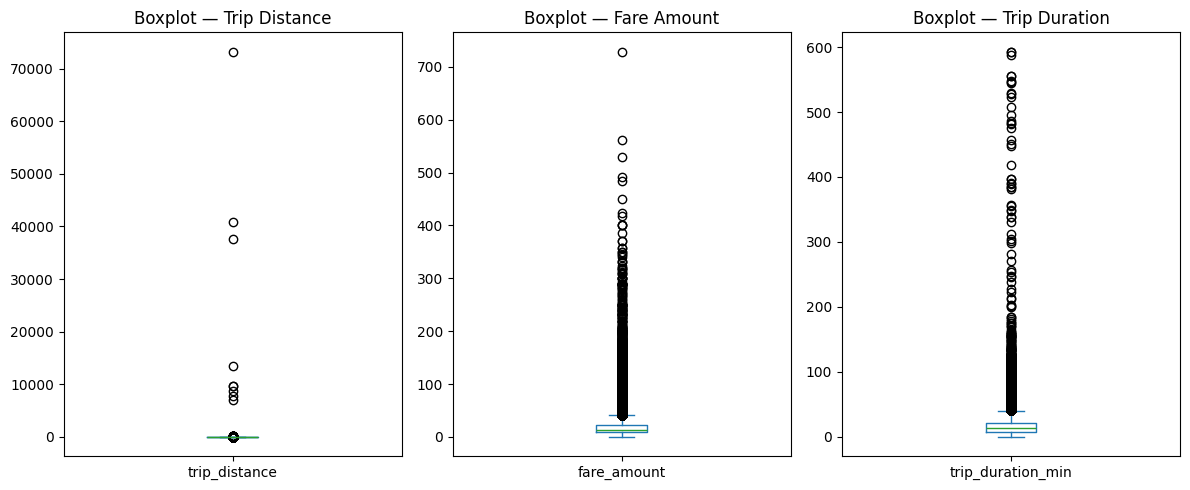

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
df["trip_distance"].plot(kind="box")
plt.title("Boxplot — Trip Distance")

plt.subplot(1,3,2)
df["fare_amount"].plot(kind="box")
plt.title("Boxplot — Fare Amount")

plt.subplot(1,3,3)
df["trip_duration_min"].plot(kind="box")
plt.title("Boxplot — Trip Duration")

plt.tight_layout()
plt.show()



In [24]:
# removing outliers
df_no_outliers = df[
    (df["trip_distance"].between(df["trip_distance"].quantile(0.25) - 1.5 * (df["trip_distance"].quantile(0.75) - df["trip_distance"].quantile(0.25)),
                                 df["trip_distance"].quantile(0.75) + 1.5 * (df["trip_distance"].quantile(0.75) - df["trip_distance"].quantile(0.25)))) &
    (df["fare_amount"].between(df["fare_amount"].quantile(0.25) - 1.5 * (df["fare_amount"].quantile(0.75) - df["fare_amount"].quantile(0.25)),
                               df["fare_amount"].quantile(0.75) + 1.5 * (df["fare_amount"].quantile(0.75) - df["fare_amount"].quantile(0.25))))
]
print("Removed outliers. New shape:", df_no_outliers.shape)


Removed outliers. New shape: (320785, 28)


In [25]:
print(df["trip_distance"].describe())


count    371561.000000
mean          4.082320
std         155.620161
min           0.010000
25%           1.100000
50%           1.810000
75%           3.490000
max       73223.800000
Name: trip_distance, dtype: float64


In [26]:
# Remove unrealistic trip distances
df = df[df["trip_distance"] <= 50]
df = df[df["trip_distance"] > 0.1]


In [27]:
print(df["trip_distance"].describe())

count    370277.00000
mean          3.52509
std           4.50535
min           0.11000
25%           1.10000
50%           1.82000
75%           3.50000
max          49.42000
Name: trip_distance, dtype: float64


> **Observation:** Trip distances above 50 miles and below 0.1 miles are removed as unrealistic. The IQR method identifies a large number of fare and distance outliers, which are visualised via boxplots above.

### 3.8 Top Pickup & Dropoff Locations

In [28]:
# TOP PICKUP & DROPOFF LOCATIONS 
print("\n Top Pickup Zones:")
print(df["PULocationID"].value_counts().head(10))


 Top Pickup Zones:
PULocationID
132    18863
237    17735
161    17301
236    15725
162    13317
138    12990
186    12833
230    12364
142    12179
170    10986
Name: count, dtype: int64


In [29]:
print("\n Top Dropoff Zones:")
print(df["DOLocationID"].value_counts().head(10))


 Top Dropoff Zones:
DOLocationID
236    16491
237    15687
161    14379
230    11616
170    11152
162    10611
142    10491
239    10418
141     9800
68      9456
Name: count, dtype: int64


In [30]:
# TRIPS PER MONTH 
print("\n Trips per Month:")
print(df.groupby("year_month").size())


 Trips per Month:
year_month
2023-01    29913
2023-02    28359
2023-03    33186
2023-04    32089
2023-05    34245
2023-06    32177
2023-07    28159
2023-08    27270
2023-09    27062
2023-10    33523
2023-11    31801
2023-12    32493
dtype: int64


## 4. Exploratory Data Analysis

### 4.1 Distributions & Visualisations

Histograms and scatter plots to understand the distribution of key numeric variables.

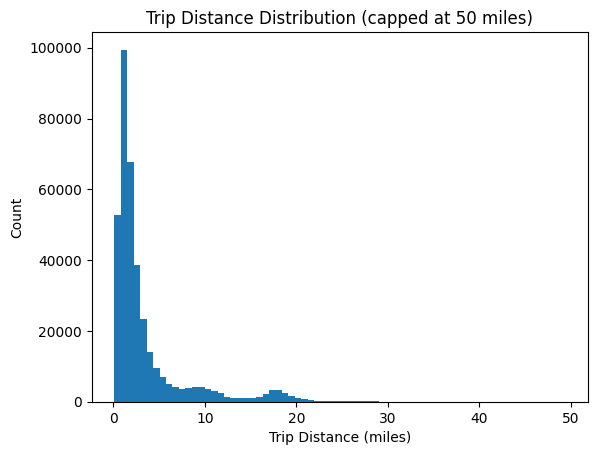

In [31]:

# Histogram: Trip Distance
plt.hist(df["trip_distance"].clip(upper=50), bins=70)
plt.title("Trip Distance Distribution (capped at 50 miles)")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Count")
plt.show()

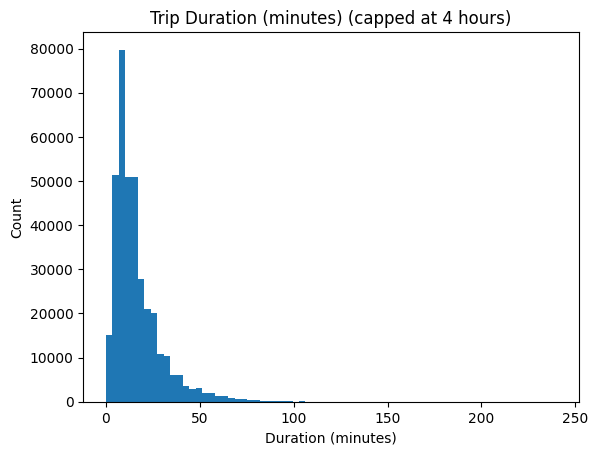

In [32]:
# Histogram: Trip Duration
plt.hist(df["trip_duration_min"].clip(upper=240), bins=70)
plt.title("Trip Duration (minutes) (capped at 4 hours)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

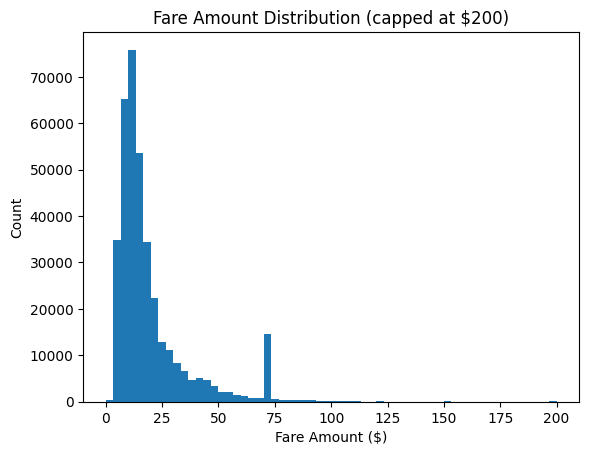

In [33]:
# Histogram: Fare Amount
plt.hist(df["fare_amount"].clip(upper=200), bins=60)
plt.title("Fare Amount Distribution (capped at $200)")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Count")
plt.show()

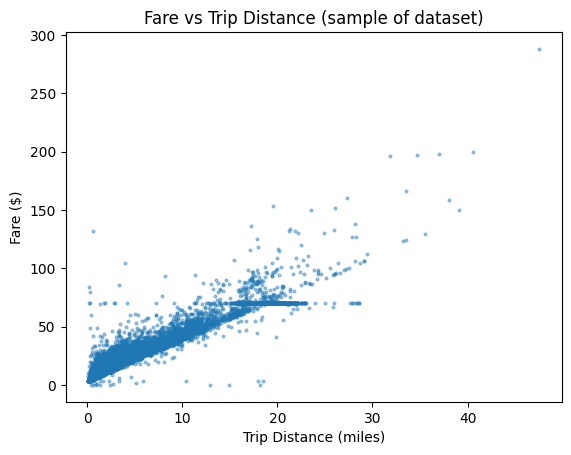

In [34]:
# Scatter: Distance vs Fare
sample = df.sample(n=min(20000, len(df)), random_state=42)
plt.scatter(sample["trip_distance"], sample["fare_amount"], alpha=0.4, s=4)
plt.title("Fare vs Trip Distance (sample of dataset)")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare ($)")
plt.show()

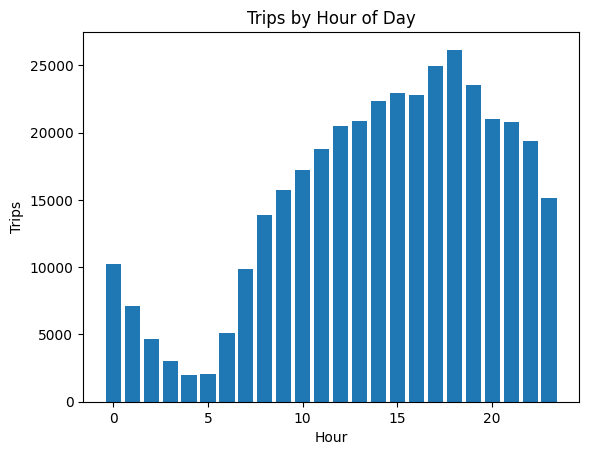

In [35]:
# Trips by hour of day
plt.bar(df["pickup_hour"].value_counts().sort_index().index,
        df["pickup_hour"].value_counts().sort_index().values)
plt.title("Trips by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

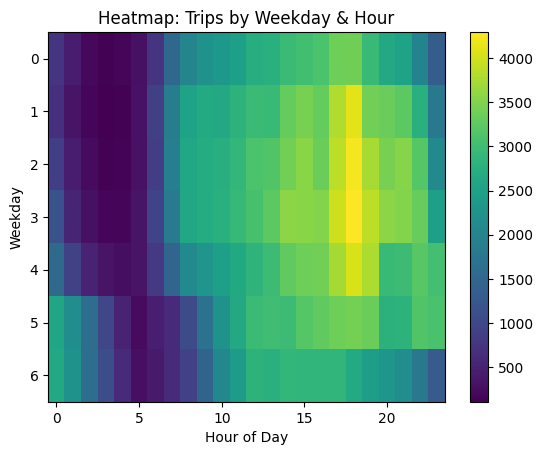

In [36]:
# Heatmap: weekday vs hour
pivot = df.pivot_table(index="pickup_weekday",
                       columns="pickup_hour",
                       values="trip_distance",
                       aggfunc="count",
                       fill_value=0)

pivot = pivot.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

plt.imshow(pivot, aspect="auto")
plt.title("Heatmap: Trips by Weekday & Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")
plt.colorbar()
plt.show()

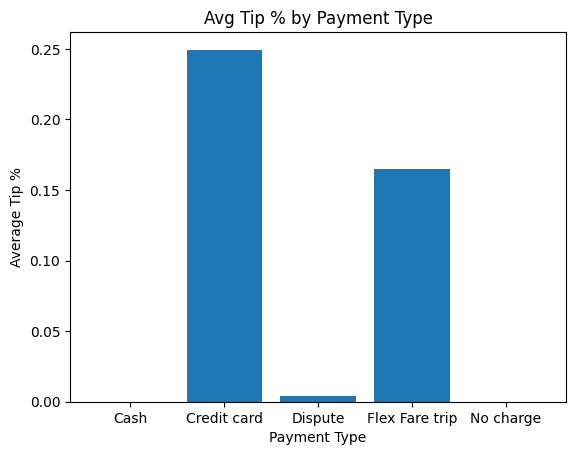

In [37]:
# Tip Percentage vs Payment type
df["tip_pct"] = np.where(df["fare_amount"] > 0, df["tip_amount"] / df["fare_amount"], 0)

plt.bar(df.groupby("payment_type")["tip_pct"].mean().index.astype(str),
        df.groupby("payment_type")["tip_pct"].mean().values)
plt.title("Avg Tip % by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Tip %")
plt.show()

> **Observation:** Trip distances and fare amounts are right-skewed with most trips being short (under 5 miles) and fares under \$30. Demand peaks between 6–9 PM on weekdays, with Friday evenings being the busiest period.

### 4.2 Univariate Analysis

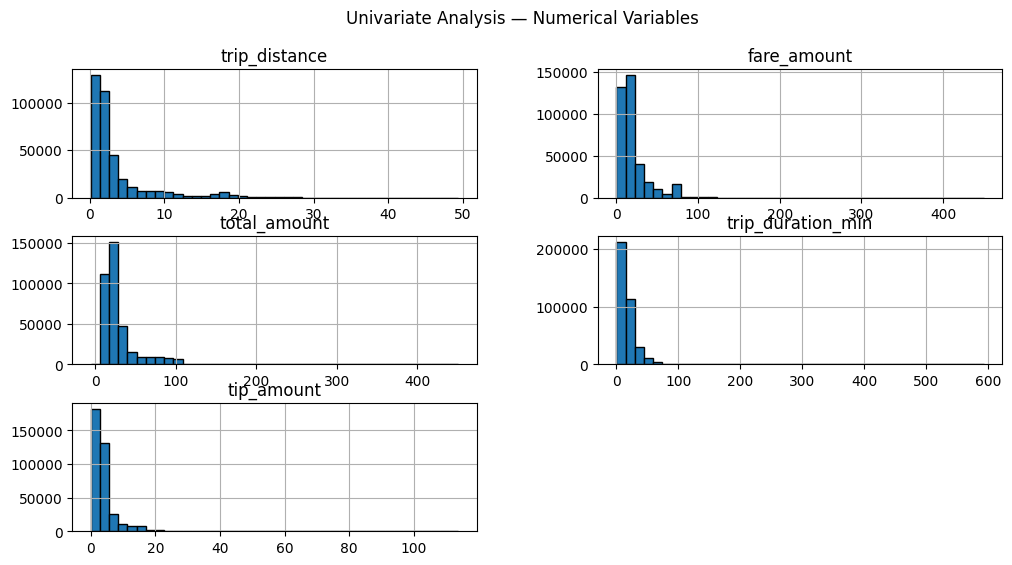

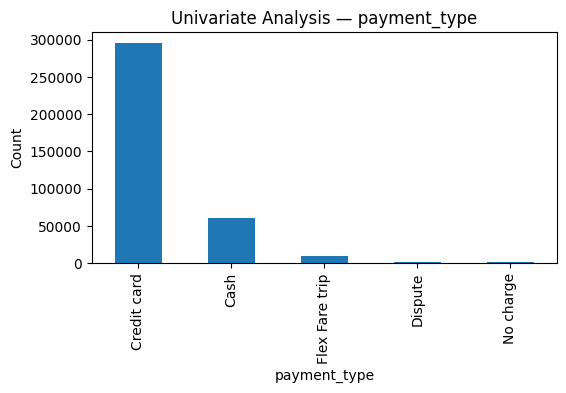

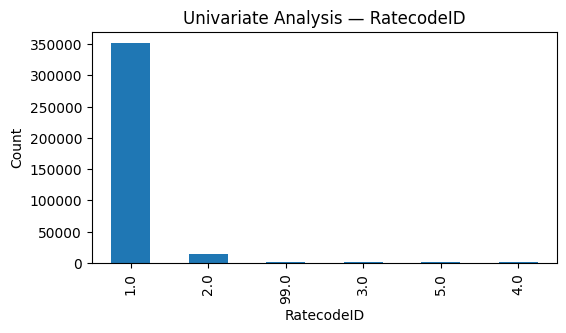

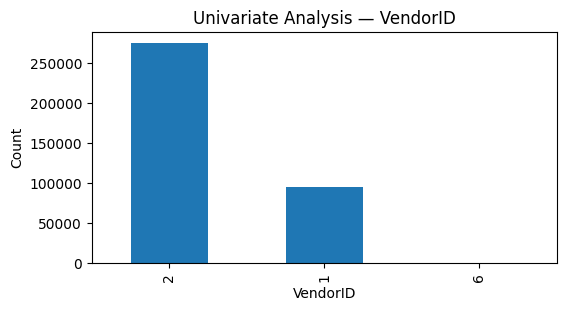

In [38]:
numeric_cols = ["trip_distance", "fare_amount", "total_amount", "trip_duration_min", "tip_amount"]
categorical_cols = ["payment_type", "RatecodeID", "VendorID"]

# Histograms for numerical features
df[numeric_cols].hist(bins=40, figsize=(12, 6), edgecolor="black")
plt.suptitle("Univariate Analysis — Numerical Variables")
plt.show()

# Barplots for categorical features
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Univariate Analysis — {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


> **Observation:** Numerical variables confirm right-skewed distributions. Credit card is the dominant payment method. Most trips are single-passenger.

### 4.3 Bivariate Analysis

#### Numerical vs Numerical (Scatter)

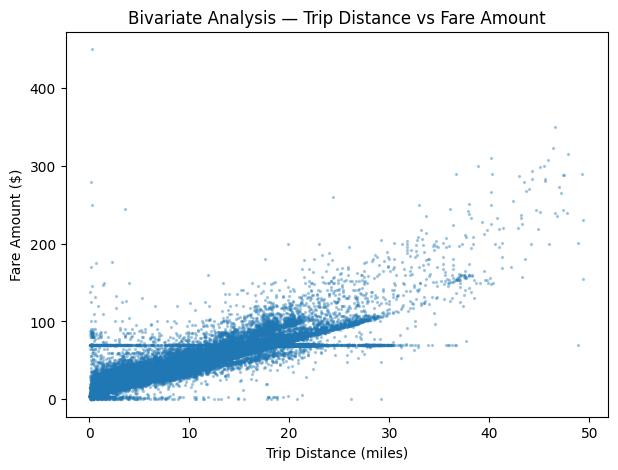

In [39]:
plt.figure(figsize=(7,5))
plt.scatter(df["trip_distance"], df["fare_amount"], alpha=0.3, s=2)
plt.title("Bivariate Analysis — Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.show()


> **Observation:** A clear positive linear relationship exists between trip distance and fare amount, confirming that distance is a strong predictor of fare.

#### Categorical vs Numerical (Boxplot)

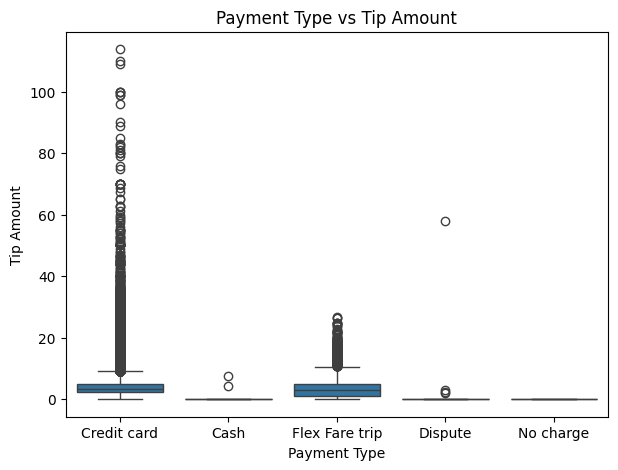

In [40]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["payment_type"], y=df["tip_amount"])
plt.title("Payment Type vs Tip Amount")
plt.xlabel("Payment Type")
plt.ylabel("Tip Amount")
plt.show()


> **Observation:** Credit card payments are associated with significantly higher tip amounts compared to cash or other payment types, likely because tip fields are auto-populated for card transactions.

#### Time vs Numerical (Line)

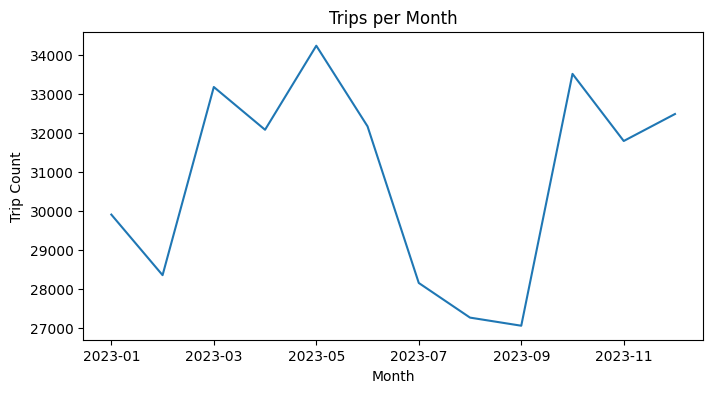

In [41]:
trips_month = df.groupby("year_month").size()
trips_month.plot(figsize=(8,4))
plt.title("Trips per Month")
plt.xlabel("Month")
plt.ylabel("Trip Count")
plt.show()


> **Observation:** Trip volume shows monthly variation in the dataset, reflecting seasonal demand patterns in NYC taxi usage.

### 4.4 Multivariate Analysis

#### Tip Percentage by Payment Type

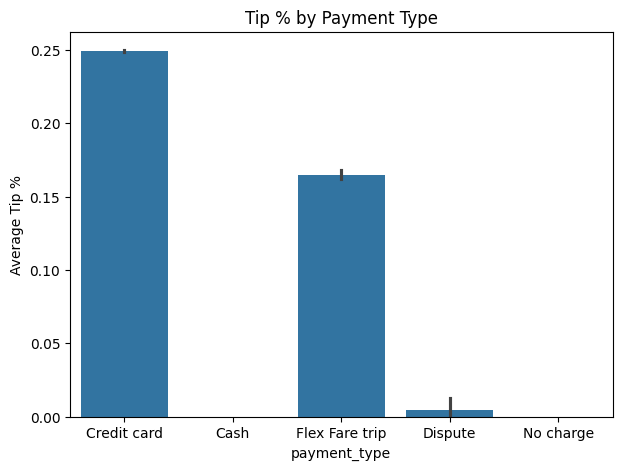

In [42]:
df["tip_pct"] = np.where(df["fare_amount"] > 0, df["tip_amount"] / df["fare_amount"], 0)

plt.figure(figsize=(7,5))
sns.barplot(x="payment_type", y="tip_pct", data=df)
plt.title("Tip % by Payment Type")
plt.ylabel("Average Tip %")
plt.show()


#### Demand Heatmap — Weekday vs Hour

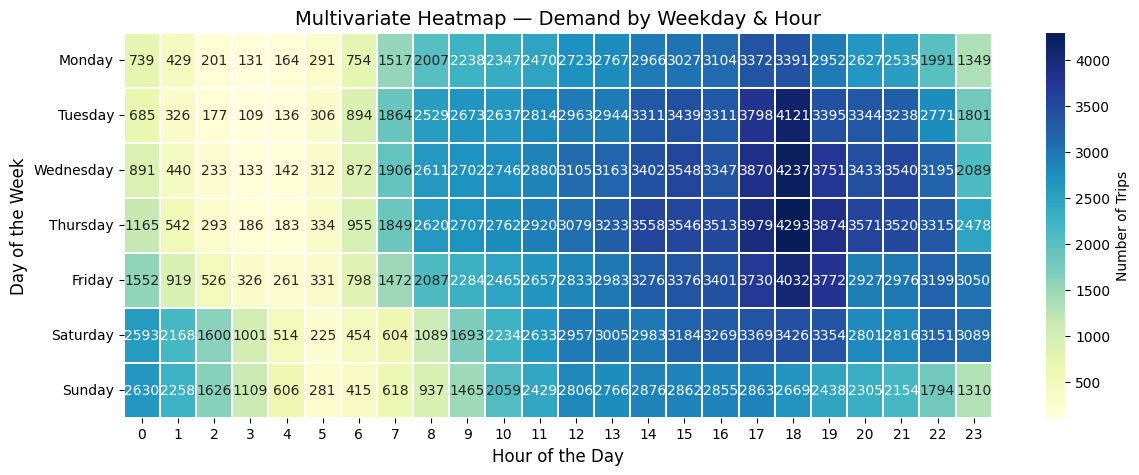

In [43]:
#  ensure datetime conversion
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

#  create weekday + hour fields
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.day_name()
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

#  Pivot table (Weekday vs Hour)
pivot = df.pivot_table(
    index="pickup_weekday",
    columns="pickup_hour",
    values="trip_distance",
    aggfunc="count",
    fill_value=0
)

ordered_weekdays = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]
pivot = pivot.reindex(ordered_weekdays)

plt.figure(figsize=(14, 5))
sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.3,
    cbar_kws={"label": "Number of Trips"}
)

plt.title("Multivariate Heatmap — Demand by Weekday & Hour", fontsize=14)
plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Day of the Week", fontsize=12)
plt.show()







> **Observation:** The heatmap reveals that demand is highest on Friday and Thursday evenings (5–8 PM) and lower on Sunday mornings. This pattern is consistent with commuter and nightlife travel behaviour.

## 5. Correlation Matrix & Heatmap

All columns are encoded numerically to compute a full correlation matrix. This helps identify multicollinearity and relationships between features and the target variables.

In [44]:
#  Create trip duration column (in minutes)
df["trip_duration_min"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60


 Total columns included in correlation: 29
Columns used:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_borough', 'pickup_zone', 'dropoff_borough', 'dropoff_zone', 'payment_method', 'year_month', 'trip_duration_min', 'pickup_hour', 'pickup_weekday', 'tip_pct']

 FULL CORRELATION MATRIX:
                       VendorID  tpep_pickup_datetime  tpep_dropoff_datetime  \
VendorID               1.000000              0.024824               0.024825   
tpep_pickup_datetime   0.024824              1.000000               1.000000   
tpep_dropoff_datetime  0.024825              1.000000               1.000000   
passenger_count        0.091274              0.006589               0.006592   
trip_distance          0

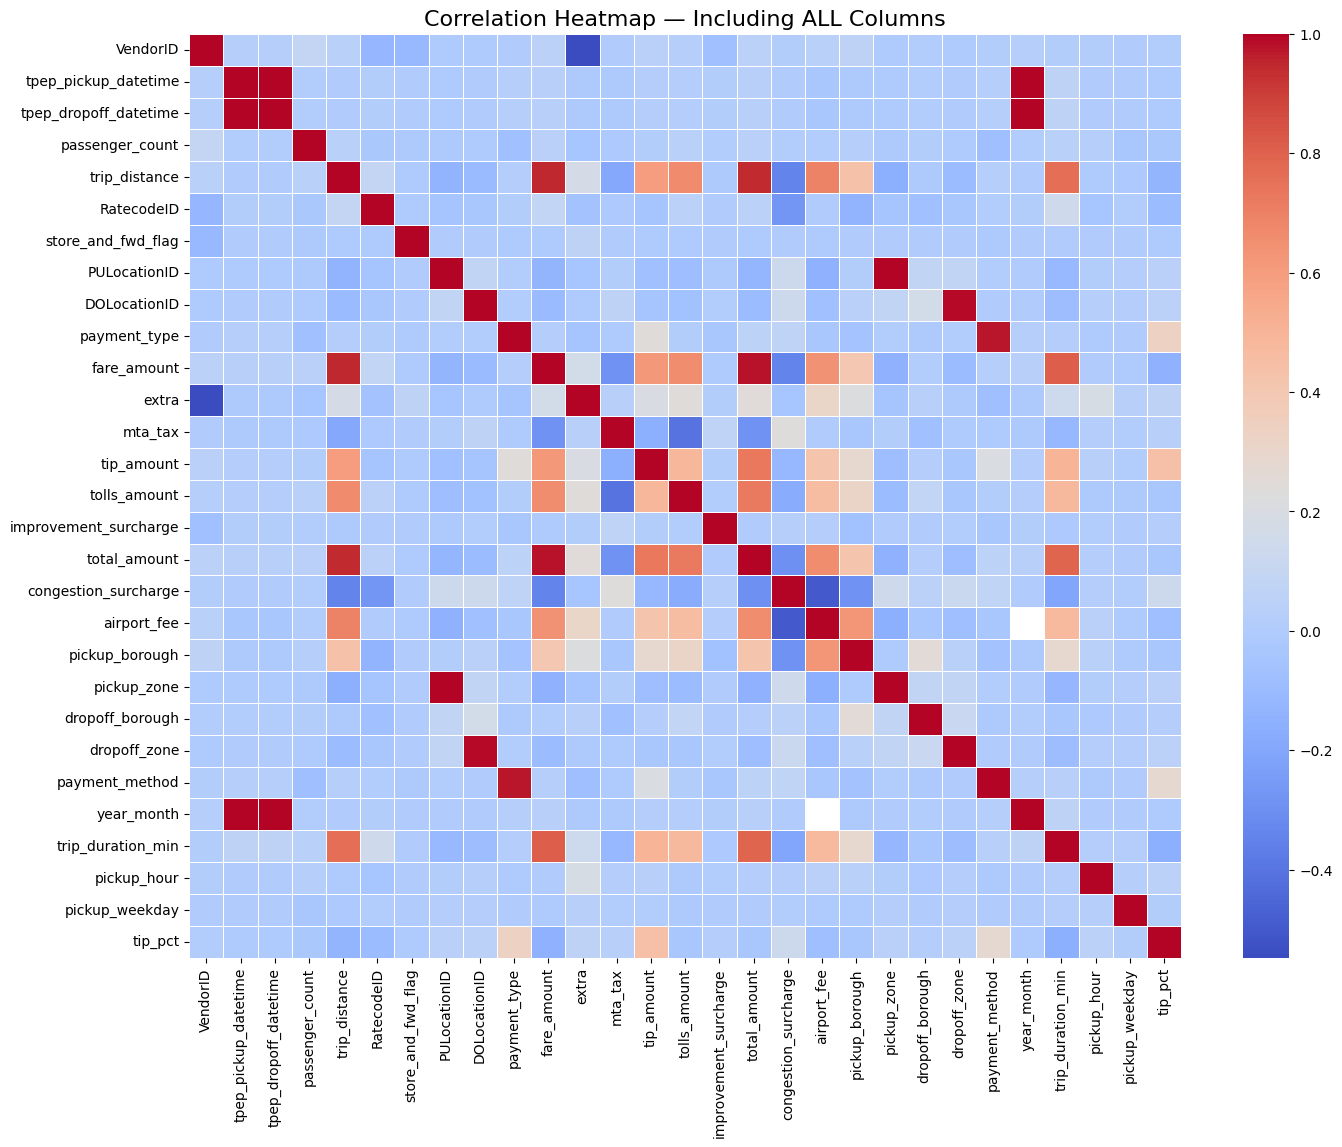

In [45]:
from sklearn.preprocessing import LabelEncoder


df_corr = df.copy()

#  Convert datetime columns into numerical values
for col in df_corr.select_dtypes(include=["datetime64[ns]"]):
    df_corr[col] = df_corr[col].astype("int64")  # convert to timestamp (nanoseconds)

#  Label encode categorical columns (VendorID, payment_type, etc.)
label_encoder = LabelEncoder()

for col in df_corr.select_dtypes(include=["object", "category"]):
    df_corr[col] = label_encoder.fit_transform(df_corr[col].astype(str))

numeric_df = df_corr.select_dtypes(include=["int64", "float64", "int32", "float32"])

print(f" Total columns included in correlation: {numeric_df.shape[1]}")
print("Columns used:")
print(list(numeric_df.columns))

#  Compute correlation matrix of ALL columns
corr_matrix = numeric_df.corr()

print("\n FULL CORRELATION MATRIX:")
print(corr_matrix)

#  Heatmap of all columns
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix,
    annot=False,     # change to True if you want the numbers printed inside
    cmap="coolwarm",
    linewidths=0.4
)

plt.title("Correlation Heatmap — Including ALL Columns", fontsize=16)
plt.show()


> **Observation:** `fare_amount` shows the strongest positive correlation with `trip_distance` and `trip_duration_min`. `total_amount` is highly correlated with `fare_amount` (expected, as it is a sum of fare components) and should not be used as a feature in fare prediction models.

## 6. Feature Engineering

New features are derived from datetime fields and location data to improve model predictive power. A demand level indicator is also created based on trip volume by weekday-hour slot.

In [46]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer


In [47]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

In [48]:
# Pickup time features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek   # Monday=0, Sunday=6
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month
df["pickup_year"] = df["tpep_pickup_datetime"].dt.year

In [49]:
df["trip_duration_minutes"] = (
    (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
)

In [50]:
df["same_borough_trip"] = (df["pickup_borough"] == df["dropoff_borough"]).astype(int)
df["same_zone_trip"] = (df["pickup_zone"] == df["dropoff_zone"]).astype(int)

In [51]:
df["year_month"] = df["year_month"].astype(str)

df["year_from_year_month"] = df["year_month"].str[:4]
df["month_from_year_month"] = df["year_month"].str[-2:]

In [52]:
df["distance_per_passenger"] = df["trip_distance"] / df["passenger_count"].replace(0, np.nan)

In [53]:
duplicate_cols = [
    "pickup_borough.1",
    "pickup_zone.1",
    "dropoff_borough.1",
    "dropoff_zone.1"
]

df = df.drop(columns=[col for col in duplicate_cols if col in df.columns])

In [54]:
# Count trips for each weekday-hour combination
demand_counts = (
    df.groupby(["pickup_dayofweek", "pickup_hour"])
      .size()
      .reset_index(name="trip_count_slot")
)

# Create demand level using quartiles
demand_counts["demand_level"] = pd.qcut(
    demand_counts["trip_count_slot"],
    q=4,
    labels=["low", "medium", "high", "very_high"]
)

# Merge demand level back into original dataframe
df = df.merge(
    demand_counts[["pickup_dayofweek", "pickup_hour", "trip_count_slot", "demand_level"]],
    on=["pickup_dayofweek", "pickup_hour"],
    how="left"
)

# Preview
print(df[["pickup_dayofweek", "pickup_hour", "trip_count_slot", "demand_level"]].head())

   pickup_dayofweek  pickup_hour  trip_count_slot demand_level
0                 6            4              606          low
1                 1           23             1801       medium
2                 1           18             4121    very_high
3                 1           21             3238    very_high
4                 1           17             3798    very_high


In [55]:
cols_to_drop = [
    "fare_amount",              # target, remove from X later
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "airport_fee",
    "payment_type",
    "payment_method",
    "pickup_borough.1",
    "pickup_zone.1",
    "dropoff_borough.1",
    "dropoff_zone.1"
]

existing_drop_cols = [col for col in cols_to_drop if col in df.columns]
print(existing_drop_cols)

['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'payment_type', 'payment_method']


In [56]:
# Keep only valid fare values
df = df[df["fare_amount"].notna()]
df = df[df["fare_amount"] > 0]

# Keep only valid trip distance
df = df[df["trip_distance"].notna()]
df = df[df["trip_distance"] >= 0]

# Keep only valid trip duration
df = df[df["trip_duration_minutes"].notna()]
df = df[df["trip_duration_minutes"] > 0]

In [57]:
# Trim extreme outliers using percentiles
fare_low, fare_high = df["fare_amount"].quantile([0.01, 0.99])
dist_low, dist_high = df["trip_distance"].quantile([0.01, 0.99])
dur_low, dur_high = df["trip_duration_minutes"].quantile([0.01, 0.99])

df = df[
    (df["fare_amount"].between(fare_low, fare_high)) &
    (df["trip_distance"].between(dist_low, dist_high)) &
    (df["trip_duration_minutes"].between(dur_low, dur_high))
]

In [58]:
feature_cols = [
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "pickup_borough",
    "pickup_zone",
    "dropoff_borough",
    "dropoff_zone",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day",
    "pickup_month",
    "pickup_year",
    "trip_duration_minutes",
    "same_borough_trip",
    "same_zone_trip",
    "distance_per_passenger",
    "trip_count_slot",
    "demand_level"
]

In [59]:
feature_cols = [col for col in feature_cols if col in df.columns]
print(feature_cols)

['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'pickup_borough', 'pickup_zone', 'dropoff_borough', 'dropoff_zone', 'pickup_hour', 'pickup_dayofweek', 'pickup_day', 'pickup_month', 'pickup_year', 'trip_duration_minutes', 'same_borough_trip', 'same_zone_trip', 'distance_per_passenger', 'trip_count_slot', 'demand_level']


In [60]:
X = df[feature_cols].copy()
y = df["fare_amount"].copy()

print(X.shape)
print(y.shape)

(357543, 22)
(357543,)


In [61]:
print(X.isnull().sum().sort_values(ascending=False))

distance_per_passenger    5391
dropoff_zone              3086
pickup_zone               3046
dropoff_borough            579
pickup_borough              64
VendorID                     0
PULocationID                 0
store_and_fwd_flag           0
RatecodeID                   0
trip_distance                0
passenger_count              0
DOLocationID                 0
pickup_dayofweek             0
pickup_hour                  0
pickup_day                   0
pickup_month                 0
trip_duration_minutes        0
pickup_year                  0
same_borough_trip            0
same_zone_trip               0
trip_count_slot              0
demand_level                 0
dtype: int64


In [62]:
numeric_features = [
    "passenger_count",
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day",
    "pickup_month",
    "trip_duration_minutes",
    "same_borough_trip",
    "same_zone_trip",
    "distance_per_passenger",
    "trip_count_slot"
]
numeric_features = [col for col in numeric_features if col in X.columns]

In [63]:
categorical_features = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "pickup_borough",
    "pickup_zone",
    "dropoff_borough",
    "dropoff_zone",
    "demand_level"
]
categorical_features = [col for col in categorical_features if col in X.columns]

In [64]:
print(df[["passenger_count", "distance_per_passenger"]].isnull().sum())
print((df["passenger_count"] == 0).sum())

passenger_count              0
distance_per_passenger    5391
dtype: int64
5391


In [65]:
# Numeric columns: median imputation
for col in numeric_features:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Categorical columns: most frequent imputation
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

In [66]:
df = df[df["fare_amount"].notna()]
df = df[df["fare_amount"] > 0]
df = df[df["trip_distance"].notna()]
df = df[df["trip_distance"] >= 0]
df = df[df["trip_duration_minutes"].notna()]
df = df[df["trip_duration_minutes"] > 0]

## 7. Modelling — Fare Amount Prediction

Three regression models are trained to predict `fare_amount`: Linear Regression (baseline), Random Forest, and Gradient Boosting. Each model uses the same feature set with appropriate preprocessing (StandardScaler for numeric, OneHotEncoder for categorical).

### 7.1 Linear Regression (Baseline)

In [67]:

X = df[feature_cols].copy()
y = df["fare_amount"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (286034, 22)
X_test: (71509, 22)
y_train: (286034,)
y_test: (71509,)


In [68]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'trip_duration_minutes', 'same_borough_trip', 'same_zone_trip', 'distance_per_passenger', 'trip_count_slot']
Categorical features: ['store_and_fwd_flag', 'pickup_borough', 'pickup_zone', 'dropoff_borough', 'dropoff_zone', 'demand_level']


In [69]:
forced_categorical = ["VendorID", "RatecodeID", "PULocationID", "DOLocationID"]

for col in forced_categorical:
    if col in numeric_features:
        numeric_features.remove(col)
        categorical_features.append(col)

print("Updated numeric:", numeric_features)
print("Updated categorical:", categorical_features)

Updated numeric: ['passenger_count', 'trip_distance', 'trip_duration_minutes', 'same_borough_trip', 'same_zone_trip', 'distance_per_passenger', 'trip_count_slot']
Updated categorical: ['store_and_fwd_flag', 'pickup_borough', 'pickup_zone', 'dropoff_borough', 'dropoff_zone', 'demand_level', 'VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']


In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])



In [71]:
# Fit
baseline_model.fit(X_train, y_train)

# Predict
y_train_pred_lr = baseline_model.predict(X_train)
y_test_pred_lr = baseline_model.predict(X_test)

# Metrics
mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
rmse_train_lr = np.sqrt(mse_train_lr)
r2_train_lr = r2_score(y_train, y_train_pred_lr)

mse_test_lr = mean_squared_error(y_test, y_test_pred_lr)
rmse_test_lr = np.sqrt(mse_test_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

print("Linear Regression Train MSE:", mse_train_lr)
print("Linear Regression Train RMSE:", rmse_train_lr)
print("Linear Regression Train R²:", r2_train_lr)
print()
print("Linear Regression Test MSE:", mse_test_lr)
print("Linear Regression Test RMSE:", rmse_test_lr)
print("Linear Regression Test R²:", r2_test_lr)

Linear Regression Train MSE: 4.740506063203865
Linear Regression Train RMSE: 2.1772703238697453
Linear Regression Train R²: 0.9770655774752655

Linear Regression Test MSE: 5.280114261672084
Linear Regression Test RMSE: 2.2978499214857537
Linear Regression Test R²: 0.9746306930946662


> **Observation:** Linear Regression establishes the baseline performance. It captures the linear relationship between distance and fare but may miss non-linear interactions.

### 7.2 Random Forest

In [72]:
fare_feature_cols_fast = [
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day",
    "pickup_month",
    "pickup_year",
    "trip_duration_minutes",
    "same_borough_trip",
    "same_zone_trip",
    "distance_per_passenger",
    "trip_count_slot",
    "demand_level"
]

fare_feature_cols_fast = [col for col in fare_feature_cols_fast if col in df.columns]

In [73]:
df_fare_rf = df.copy()

df_fare_rf = df_fare_rf[df_fare_rf["fare_amount"].notna()]
df_fare_rf = df_fare_rf[df_fare_rf["fare_amount"] > 0]

# sample for speed
df_fare_rf = df_fare_rf.sample(n=50000, random_state=42)

In [74]:
X_fare_rf = df_fare_rf[fare_feature_cols_fast].copy()
y_fare_rf = df_fare_rf["fare_amount"].copy()

In [75]:
X_train_fare_rf, X_test_fare_rf, y_train_fare_rf, y_test_fare_rf = train_test_split(
    X_fare_rf, y_fare_rf, test_size=0.2, random_state=42
)

In [76]:
numeric_features_fare_rf = X_train_fare_rf.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_fare_rf = X_train_fare_rf.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

forced_categorical = ["VendorID", "RatecodeID", "PULocationID", "DOLocationID"]

for col in forced_categorical:
    if col in numeric_features_fare_rf:
        numeric_features_fare_rf.remove(col)
    if col in X_train_fare_rf.columns and col not in categorical_features_fare_rf:
        categorical_features_fare_rf.append(col)

print("Numeric:", numeric_features_fare_rf)
print("Categorical:", categorical_features_fare_rf)

Numeric: ['passenger_count', 'trip_distance', 'trip_duration_minutes', 'same_borough_trip', 'same_zone_trip', 'distance_per_passenger', 'trip_count_slot']
Categorical: ['store_and_fwd_flag', 'demand_level', 'VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']


In [77]:
preprocessor_fare_rf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_fare_rf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_fare_rf)
    ]
)

In [78]:
rf_fare_fast = Pipeline(steps=[
    ("preprocessor", preprocessor_fare_rf),
    ("model", RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

rf_fare_fast.fit(X_train_fare_rf, y_train_fare_rf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['passenger_count',
                                                   'trip_distance',
                                                   'trip_duration_minutes',
                                                   'same_borough_trip',
                                                   'same_zone_trip',
                                                   'distance_per_passenger',
                                                   'trip_count_slot']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['store_and_fwd_flag',
                                                   'demand_level', 'VendorID',
                                                   'RatecodeID', 'PULocationID',
                                                   'DOLocationID'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, max_features='sqrt',
                                       min_samples_leaf=4, min_samples_split=10,
                                       n_estimators=30, n_jobs=-1,
                                       random_state=42))])

In [79]:
y_train_pred_fare_rf = rf_fare_fast.predict(X_train_fare_rf)
y_test_pred_fare_rf = rf_fare_fast.predict(X_test_fare_rf)

mse_train_fare_rf = mean_squared_error(y_train_fare_rf, y_train_pred_fare_rf)
rmse_train_fare_rf = np.sqrt(mse_train_fare_rf)
r2_train_fare_rf = r2_score(y_train_fare_rf, y_train_pred_fare_rf)

mse_test_fare_rf = mean_squared_error(y_test_fare_rf, y_test_pred_fare_rf)
rmse_test_fare_rf = np.sqrt(mse_test_fare_rf)
r2_test_fare_rf = r2_score(y_test_fare_rf, y_test_pred_fare_rf)

print("Fare Random Forest Train MSE:", mse_train_fare_rf)
print("Fare Random Forest Train RMSE:", rmse_train_fare_rf)
print("Fare Random Forest Train R²:", r2_train_fare_rf)
print()
print("Fare Random Forest Test MSE:", mse_test_fare_rf)
print("Fare Random Forest Test RMSE:", rmse_test_fare_rf)
print("Fare Random Forest Test R²:", r2_test_fare_rf)

Fare Random Forest Train MSE: 15.252026069688114
Fare Random Forest Train RMSE: 3.905384240979127
Fare Random Forest Train R²: 0.9267252733820105

Fare Random Forest Test MSE: 15.606487207867866
Fare Random Forest Test RMSE: 3.9505046776162493
Fare Random Forest Test R²: 0.9250513440740122


> **Observation:** Random Forest significantly improves over Linear Regression by capturing non-linear relationships. The model is trained on a 50,000-row sample for computational efficiency.

### 7.3 Gradient Boosting

In [80]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

# Fit
gbr_model.fit(X_train, y_train)

# Predict
y_train_pred_gbr = gbr_model.predict(X_train)
y_test_pred_gbr = gbr_model.predict(X_test)

# Metrics
mse_train_gbr = mean_squared_error(y_train, y_train_pred_gbr)
rmse_train_gbr = np.sqrt(mse_train_gbr)
r2_train_gbr = r2_score(y_train, y_train_pred_gbr)

mse_test_gbr = mean_squared_error(y_test, y_test_pred_gbr)
rmse_test_gbr = np.sqrt(mse_test_gbr)
r2_test_gbr = r2_score(y_test, y_test_pred_gbr)

print("Gradient Boosting Train MSE:", mse_train_gbr)
print("Gradient Boosting Train RMSE:", rmse_train_gbr)
print("Gradient Boosting Train R²:", r2_train_gbr)
print()
print("Gradient Boosting Test MSE:", mse_test_gbr)
print("Gradient Boosting Test RMSE:", rmse_test_gbr)
print("Gradient Boosting Test R²:", r2_test_gbr)

Gradient Boosting Train MSE: 2.0867869818325158
Gradient Boosting Train RMSE: 1.4445715564943524
Gradient Boosting Train R²: 0.9899041887675349

Gradient Boosting Test MSE: 2.2198116170863442
Gradient Boosting Test RMSE: 1.4899032240673702
Gradient Boosting Test R²: 0.9893344955440311


> **Observation:** Gradient Boosting typically outperforms Random Forest on tabular data due to its sequential error-correction approach.

### 7.4 Model Comparison — Fare Amount (Before Tuning)

In [81]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train MSE": [
        mse_train_lr,
        mse_train_fare_rf,
        mse_train_gbr
    ],
    "Train RMSE": [
        rmse_train_lr,
        rmse_train_fare_rf,
        rmse_train_gbr
    ],
    "Train R2": [
        r2_train_lr,
        r2_train_fare_rf,
        r2_train_gbr
    ],
    "Test MSE": [
        mse_test_lr,
        mse_test_fare_rf,
        mse_test_gbr
    ],
    "Test RMSE": [
        rmse_test_lr,
        rmse_test_fare_rf,
        rmse_test_gbr
    ],
    "Test R2": [
        r2_test_lr,
        r2_test_fare_rf,
        r2_test_gbr
    ]
})

print(results.sort_values(by="Test RMSE"))

               Model  Train MSE  Train RMSE  Train R2   Test MSE  Test RMSE  \
2  Gradient Boosting   2.086787    1.444572  0.989904   2.219812   1.489903   
0  Linear Regression   4.740506    2.177270  0.977066   5.280114   2.297850   
1      Random Forest  15.252026    3.905384  0.926725  15.606487   3.950505   

    Test R2  
2  0.989334  
0  0.974631  
1  0.925051  


> **Observation:** Compare RMSE and R² across the three models above. Lower RMSE and higher R² indicate better performance. Gradient Boosting is expected to lead before tuning.

## 8. Modelling — Trip Distance Prediction

The same three-model pipeline is applied to predict `trip_distance`, using fare-related fields excluded from the feature set to avoid target leakage.

### 8.1 Linear Regression (Baseline)

In [83]:
trip_feature_cols = [
    "VendorID",
    "passenger_count",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "pickup_borough",
    "pickup_zone",
    "dropoff_borough",
    "dropoff_zone",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day",
    "pickup_month",
    "pickup_year",
    "same_borough_trip",
    "same_zone_trip",
    "trip_count_slot",
    "demand_level"
]

trip_feature_cols = [col for col in trip_feature_cols if col in df.columns]

# Clean rows first
df_trip = df.copy()
df_trip = df_trip[df_trip["trip_distance"].notna()]
df_trip = df_trip[df_trip["trip_distance"] > 0]

X_trip = df_trip[trip_feature_cols].copy()
y_trip = df_trip["trip_distance"].copy()

print(X_trip.shape)
print(y_trip.shape)
print(trip_feature_cols)

(357543, 19)
(357543,)
['VendorID', 'passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'pickup_borough', 'pickup_zone', 'dropoff_borough', 'dropoff_zone', 'pickup_hour', 'pickup_dayofweek', 'pickup_day', 'pickup_month', 'pickup_year', 'same_borough_trip', 'same_zone_trip', 'trip_count_slot', 'demand_level']


In [85]:
X_train_trip, X_test_trip, y_train_trip, y_test_trip = train_test_split(
    X_trip, y_trip, test_size=0.2, random_state=42
)

print("X_train_trip:", X_train_trip.shape)
print("X_test_trip:", X_test_trip.shape)

X_train_trip: (286034, 19)
X_test_trip: (71509, 19)


In [86]:
numeric_features_trip = X_train_trip.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_trip = X_train_trip.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

forced_categorical = ["VendorID", "RatecodeID", "PULocationID", "DOLocationID"]

for col in forced_categorical:
    if col in numeric_features_trip:
        numeric_features_trip.remove(col)
    if col in X_train_trip.columns and col not in categorical_features_trip:
        categorical_features_trip.append(col)

print("Numeric trip features:", numeric_features_trip)
print("Categorical trip features:", categorical_features_trip)

Numeric trip features: ['passenger_count', 'same_borough_trip', 'same_zone_trip', 'trip_count_slot']
Categorical trip features: ['store_and_fwd_flag', 'pickup_borough', 'pickup_zone', 'dropoff_borough', 'dropoff_zone', 'demand_level', 'VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']


In [87]:
preprocessor_trip = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_trip),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_trip)
    ]
)

In [88]:
#Baseline
lr_trip_model = Pipeline(steps=[
    ("preprocessor", preprocessor_trip),
    ("model", LinearRegression())
])

lr_trip_model.fit(X_train_trip, y_train_trip)

y_train_pred_lr_trip = lr_trip_model.predict(X_train_trip)
y_test_pred_lr_trip = lr_trip_model.predict(X_test_trip)

mse_train_lr_trip = mean_squared_error(y_train_trip, y_train_pred_lr_trip)
rmse_train_lr_trip = np.sqrt(mse_train_lr_trip)
r2_train_lr_trip = r2_score(y_train_trip, y_train_pred_lr_trip)

mse_test_lr_trip = mean_squared_error(y_test_trip, y_test_pred_lr_trip)
rmse_test_lr_trip = np.sqrt(mse_test_lr_trip)
r2_test_lr_trip = r2_score(y_test_trip, y_test_pred_lr_trip)

print("Trip Distance - Linear Regression Train MSE:", mse_train_lr_trip)
print("Trip Distance - Linear Regression Train RMSE:", rmse_train_lr_trip)
print("Trip Distance - Linear Regression Train R²:", r2_train_lr_trip)
print()
print("Trip Distance - Linear Regression Test MSE:", mse_test_lr_trip)
print("Trip Distance - Linear Regression Test RMSE:", rmse_test_lr_trip)
print("Trip Distance - Linear Regression Test R²:", r2_test_lr_trip)

Trip Distance - Linear Regression Train MSE: 2.2954673549955946
Trip Distance - Linear Regression Train RMSE: 1.5150799830357453
Trip Distance - Linear Regression Train R²: 0.8370358914052352

Trip Distance - Linear Regression Test MSE: 2.357509254936967
Trip Distance - Linear Regression Test RMSE: 1.5354182670975902
Trip Distance - Linear Regression Test R²: 0.8345170867886695


> **Observation:** The Linear Regression baseline for trip distance is set here.

### 8.2 Random Forest

In [89]:
#RF
trip_feature_cols_fast = [
    "VendorID",
    "passenger_count",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_day",
    "pickup_month",
    "pickup_year",
    "same_borough_trip",
    "same_zone_trip",
    "trip_count_slot",
    "demand_level"
]

trip_feature_cols_fast = [col for col in trip_feature_cols_fast if col in df.columns]

In [90]:
df_trip_rf = df.copy()

df_trip_rf = df_trip_rf[df_trip_rf["trip_distance"].notna()]
df_trip_rf = df_trip_rf[df_trip_rf["trip_distance"] > 0]

# sample for speed
df_trip_rf = df_trip_rf.sample(n=50000, random_state=42)

In [91]:
X_trip_rf = df_trip_rf[trip_feature_cols_fast].copy()
y_trip_rf = df_trip_rf["trip_distance"].copy()

In [92]:
X_train_trip_rf, X_test_trip_rf, y_train_trip_rf, y_test_trip_rf = train_test_split(
    X_trip_rf, y_trip_rf, test_size=0.2, random_state=42
)

In [93]:
numeric_features_trip_rf = X_train_trip_rf.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_trip_rf = X_train_trip_rf.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

forced_categorical = ["VendorID", "RatecodeID", "PULocationID", "DOLocationID"]

for col in forced_categorical:
    if col in numeric_features_trip_rf:
        numeric_features_trip_rf.remove(col)
    if col in X_train_trip_rf.columns and col not in categorical_features_trip_rf:
        categorical_features_trip_rf.append(col)

print("Numeric:", numeric_features_trip_rf)
print("Categorical:", categorical_features_trip_rf)

Numeric: ['passenger_count', 'same_borough_trip', 'same_zone_trip', 'trip_count_slot']
Categorical: ['store_and_fwd_flag', 'demand_level', 'VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']


In [94]:
preprocessor_trip_rf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_trip_rf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_trip_rf)
    ]
)

In [95]:
rf_trip_fast = Pipeline(steps=[
    ("preprocessor", preprocessor_trip_rf),
    ("model", RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

rf_trip_fast.fit(X_train_trip_rf, y_train_trip_rf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['passenger_count',
                                                   'same_borough_trip',
                                                   'same_zone_trip',
                                                   'trip_count_slot']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['store_and_fwd_flag',
                                                   'demand_level', 'VendorID',
                                                   'RatecodeID', 'PULocationID',
                                                   'DOLocationID'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, max_features='sqrt',
                                       min_samples_leaf=4, min_samples_split=10,
                                       n_estimators=30, n_jobs=-1,
                                       random_state=42))])

In [96]:
y_train_pred_trip_rf = rf_trip_fast.predict(X_train_trip_rf)
y_test_pred_trip_rf = rf_trip_fast.predict(X_test_trip_rf)

mse_train_trip_rf = mean_squared_error(y_train_trip_rf, y_train_pred_trip_rf)
rmse_train_trip_rf = np.sqrt(mse_train_trip_rf)
r2_train_trip_rf = r2_score(y_train_trip_rf, y_train_pred_trip_rf)

mse_test_trip_rf = mean_squared_error(y_test_trip_rf, y_test_pred_trip_rf)
rmse_test_trip_rf = np.sqrt(mse_test_trip_rf)
r2_test_trip_rf = r2_score(y_test_trip_rf, y_test_pred_trip_rf)

print("Trip Distance Random Forest Train MSE:", mse_train_trip_rf)
print("Trip Distance Random Forest Train RMSE:", rmse_train_trip_rf)
print("Trip Distance Random Forest Train R²:", r2_train_trip_rf)
print()
print("Trip Distance Random Forest Test MSE:", mse_test_trip_rf)
print("Trip Distance Random Forest Test RMSE:", rmse_test_trip_rf)
print("Trip Distance Random Forest Test R²:", r2_test_trip_rf)

Trip Distance Random Forest Train MSE: 3.6646005476372534
Trip Distance Random Forest Train RMSE: 1.9143146417549162
Trip Distance Random Forest Train R²: 0.7437520558849466

Trip Distance Random Forest Test MSE: 3.686455074148073
Trip Distance Random Forest Test RMSE: 1.9200143421724936
Trip Distance Random Forest Test R²: 0.7416655099868068


### 8.3 Gradient Boosting

In [97]:
#Gradient Boosting
gbr_trip_model = Pipeline(steps=[
    ("preprocessor", preprocessor_trip),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gbr_trip_model.fit(X_train_trip, y_train_trip)

y_train_pred_gbr_trip = gbr_trip_model.predict(X_train_trip)
y_test_pred_gbr_trip = gbr_trip_model.predict(X_test_trip)

mse_train_gbr_trip = mean_squared_error(y_train_trip, y_train_pred_gbr_trip)
rmse_train_gbr_trip = np.sqrt(mse_train_gbr_trip)
r2_train_gbr_trip = r2_score(y_train_trip, y_train_pred_gbr_trip)

mse_test_gbr_trip = mean_squared_error(y_test_trip, y_test_pred_gbr_trip)
rmse_test_gbr_trip = np.sqrt(mse_test_gbr_trip)
r2_test_gbr_trip = r2_score(y_test_trip, y_test_pred_gbr_trip)

print("Trip Distance - Gradient Boosting Train MSE:", mse_train_gbr_trip)
print("Trip Distance - Gradient Boosting Train RMSE:", rmse_train_gbr_trip)
print("Trip Distance - Gradient Boosting Train R²:", r2_train_gbr_trip)
print()
print("Trip Distance - Gradient Boosting Test MSE:", mse_test_gbr_trip)
print("Trip Distance - Gradient Boosting Test RMSE:", rmse_test_gbr_trip)
print("Trip Distance - Gradient Boosting Test R²:", r2_test_gbr_trip)

Trip Distance - Gradient Boosting Train MSE: 2.4009114682812482
Trip Distance - Gradient Boosting Train RMSE: 1.5494874856807486
Trip Distance - Gradient Boosting Train R²: 0.829550005844386

Trip Distance - Gradient Boosting Test MSE: 2.41815189348464
Trip Distance - Gradient Boosting Test RMSE: 1.5550408012282635
Trip Distance - Gradient Boosting Test R²: 0.8302603397703173


### 8.4 Model Comparison — Trip Distance (Before Tuning)

In [99]:
trip_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train MSE": [
        mse_train_lr_trip,
        mse_train_trip_rf,
        mse_train_gbr_trip
    ],
    "Train RMSE": [
        rmse_train_lr_trip,
        rmse_train_trip_rf,
        rmse_train_gbr_trip
    ],
    "Train R2": [
        r2_train_lr_trip,
        r2_train_trip_rf,
        r2_train_gbr_trip
    ],
    "Test MSE": [
        mse_test_lr_trip,
        mse_test_trip_rf,
        mse_test_gbr_trip
    ],
    "Test RMSE": [
        rmse_test_lr_trip,
        rmse_test_trip_rf,
        rmse_test_gbr_trip
    ],
    "Test R2": [
        r2_test_lr_trip,
        r2_test_trip_rf,
        r2_test_gbr_trip
    ]
})

print(trip_results.sort_values(by="Test RMSE"))

               Model  Train MSE  Train RMSE  Train R2  Test MSE  Test RMSE  \
0  Linear Regression   2.295467    1.515080  0.837036  2.357509   1.535418   
2  Gradient Boosting   2.400911    1.549487  0.829550  2.418152   1.555041   
1      Random Forest   3.664601    1.914315  0.743752  3.686455   1.920014   

    Test R2  
0  0.834517  
2  0.830260  
1  0.741666  


> **Observation:** Compare trip distance model performance. Location-based features (pickup/dropoff zones and boroughs) are expected to be the strongest predictors.

## 9. Hyperparameter Tuning

RandomizedSearchCV is used to tune the Gradient Boosting model for both targets. A 3-fold cross-validation with 15 random parameter combinations is run to find the best configuration.

### 9.1 Tuned GBR — Fare Amount

In [100]:
from sklearn.model_selection import RandomizedSearchCV

gbr_fare_tune = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_dist_gbr_fare = {
    "model__n_estimators": [100, 150, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "model__max_depth": [2, 3, 5, 7],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__max_features": [None, "sqrt", "log2"]
}

random_gbr_fare = RandomizedSearchCV(
    estimator=gbr_fare_tune,
    param_distributions=param_dist_gbr_fare,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_gbr_fare.fit(X_train, y_train)

print("Best Gradient Boosting Fare Params:", random_gbr_fare.best_params_)
print("Best CV Score (negative RMSE):", random_gbr_fare.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Gradient Boosting Fare Params: {'model__subsample': 0.8, 'model__n_estimators': 150, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best CV Score (negative RMSE): -1.4640687040985683


In [ ]:
best_gbr_fare = random_gbr_fare.best_estimator_

y_train_pred_best_gbr_fare = best_gbr_fare.predict(X_train)
y_test_pred_best_gbr_fare = best_gbr_fare.predict(X_test)
  
mse_train_best_gbr_fare = mean_squared_error(y_train, y_train_pred_best_gbr_fare)
rmse_train_best_gbr_fare = np.sqrt(mse_train_best_gbr_fare)
r2_train_best_gbr_fare = r2_score(y_train, y_train_pred_best_gbr_fare)

mse_test_best_gbr_fare = mean_squared_error(y_test, y_test_pred_best_gbr_fare)
rmse_test_best_gbr_fare = np.sqrt(mse_test_best_gbr_fare)
r2_test_best_gbr_fare = r2_score(y_test, y_test_pred_best_gbr_fare)

print("Tuned GBR Fare Train MSE:", mse_train_best_gbr_fare)
print("Tuned GBR Fare Train RMSE:", rmse_train_best_gbr_fare)
print("Tuned GBR Fare Train R2:", r2_train_best_gbr_fare)
print()
print("Tuned GBR Fare Test MSE:", mse_test_best_gbr_fare)
print("Tuned GBR Fare Test RMSE:", rmse_test_best_gbr_fare)
print("Tuned GBR Fare Test R2:", r2_test_best_gbr_fare)

Tuned GBR Fare Train MSE: 1.9750052313471709
Tuned GBR Fare Train RMSE: 1.405348793484084
Tuned GBR Fare Train R2: 0.9904449854381867

Tuned GBR Fare Test MSE: 2.1389976489320874
Tuned GBR Fare Test RMSE: 1.4625312471643426
Tuned GBR Fare Test R2: 0.9897227815277693


In [102]:
tuned_fare_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Gradient Boosting",
        "Tuned Gradient Boosting",
        
    ],
    "Train MSE": [
        mse_train_lr,
        mse_train_gbr,
        mse_train_best_gbr_fare,
        
    ],
    "Train RMSE": [
        rmse_train_lr,
        rmse_train_gbr,
        rmse_train_best_gbr_fare,
        
    ],
    "Train R2": [
        r2_train_lr,
        r2_train_gbr,
        r2_train_best_gbr_fare,
        
    ],
    "Test MSE": [
        mse_test_lr,
        mse_test_gbr,
        mse_test_best_gbr_fare,
        
    ],
    "Test RMSE": [
        rmse_test_lr,
        rmse_test_gbr,
        rmse_test_best_gbr_fare,
        
    ],
    "Test R2": [
        r2_test_lr,
        r2_test_gbr,
        r2_test_best_gbr_fare,
        
    ]
})

print(tuned_fare_results.sort_values(by="Test RMSE"))

                     Model  Train MSE  Train RMSE  Train R2  Test MSE  \
2  Tuned Gradient Boosting   1.975005    1.405349  0.990445  2.138998   
1        Gradient Boosting   2.086787    1.444572  0.989904  2.219812   
0        Linear Regression   4.740506    2.177270  0.977066  5.280114   

   Test RMSE   Test R2  
2   1.462531  0.989723  
1   1.489903  0.989334  
0   2.297850  0.974631  


> **Observation:** The tuned GBR reduces RMSE compared to the default GBR. The comparison table above shows the improvement in both train and test metrics.

### 9.2 Tuned GBR — Trip Distance

In [103]:
gbr_trip_tune = Pipeline(steps=[
    ("preprocessor", preprocessor_trip),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_dist_gbr_trip = {
    "model__n_estimators": [100, 150, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "model__max_depth": [2, 3, 5, 7],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__max_features": [None, "sqrt", "log2"]
}

random_gbr_trip = RandomizedSearchCV(
    estimator=gbr_trip_tune,
    param_distributions=param_dist_gbr_trip,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_gbr_trip.fit(X_train_trip, y_train_trip)

print("Best Gradient Boosting Trip Params:", random_gbr_trip.best_params_)
print("Best CV Score (negative RMSE):", random_gbr_trip.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Gradient Boosting Trip Params: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 7, 'model__learning_rate': 0.15}
Best CV Score (negative RMSE): -1.3182100908348928


In [104]:
best_gbr_trip = random_gbr_trip.best_estimator_

y_train_pred_best_gbr_trip = best_gbr_trip.predict(X_train_trip)
y_test_pred_best_gbr_trip = best_gbr_trip.predict(X_test_trip)

mse_train_best_gbr_trip = mean_squared_error(y_train_trip, y_train_pred_best_gbr_trip)
rmse_train_best_gbr_trip = np.sqrt(mse_train_best_gbr_trip)
r2_train_best_gbr_trip = r2_score(y_train_trip, y_train_pred_best_gbr_trip)

mse_test_best_gbr_trip = mean_squared_error(y_test_trip, y_test_pred_best_gbr_trip)
rmse_test_best_gbr_trip = np.sqrt(mse_test_best_gbr_trip)
r2_test_best_gbr_trip = r2_score(y_test_trip, y_test_pred_best_gbr_trip)

print("Tuned GBR Trip Train MSE:", mse_train_best_gbr_trip)
print("Tuned GBR Trip Train RMSE:", rmse_train_best_gbr_trip)
print("Tuned GBR Trip Train R2:", r2_train_best_gbr_trip)
print()
print("Tuned GBR Trip Test MSE:", mse_test_best_gbr_trip)
print("Tuned GBR Trip Test RMSE:", rmse_test_best_gbr_trip)
print("Tuned GBR Trip Test R2:", r2_test_best_gbr_trip)

Tuned GBR Trip Train MSE: 1.6755050204875863
Tuned GBR Trip Train RMSE: 1.2944130022862048
Tuned GBR Trip Train R2: 0.8810494161393392

Tuned GBR Trip Test MSE: 1.7336775586028939
Tuned GBR Trip Test RMSE: 1.3166918996496082
Tuned GBR Trip Test R2: 0.8783063046874933


In [105]:
tuned_trip_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Gradient Boosting",
        "Tuned Gradient Boosting",
        
    ],
    "Train MSE": [
        mse_train_lr_trip,
        mse_train_gbr_trip,
        mse_train_best_gbr_trip,
        
    ],
    "Train RMSE": [
        rmse_train_lr_trip,
        rmse_train_gbr_trip,
        rmse_train_best_gbr_trip,
        
    ],
    "Train R2": [
        r2_train_lr_trip,
        r2_train_gbr_trip,
        r2_train_best_gbr_trip,
        
    ],
    "Test MSE": [
        mse_test_lr_trip,
        mse_test_gbr_trip,
        mse_test_best_gbr_trip,
        
    ],
    "Test RMSE": [
        rmse_test_lr_trip,
        rmse_test_gbr_trip,
        rmse_test_best_gbr_trip,
        
    ],
    "Test R2": [
        r2_test_lr_trip,
        r2_test_gbr_trip,
        r2_test_best_gbr_trip,
        
    ]
})

print(tuned_trip_results.sort_values(by="Test RMSE"))

                     Model  Train MSE  Train RMSE  Train R2  Test MSE  \
2  Tuned Gradient Boosting   1.675505    1.294413  0.881049  1.733678   
0        Linear Regression   2.295467    1.515080  0.837036  2.357509   
1        Gradient Boosting   2.400911    1.549487  0.829550  2.418152   

   Test RMSE   Test R2  
2   1.316692  0.878306  
0   1.535418  0.834517  
1   1.555041  0.830260  


> **Observation:** Tuning similarly improves trip distance predictions. The best parameters and CV scores are printed above.

## 10. Artificial Neural Network (ANN) Models

Deep learning models are trained as an additional benchmark. The preprocessor from the Linear Regression pipeline is reused to transform input features. Early stopping prevents overfitting.

### 10.1 ANN — Fare Amount

In [116]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [117]:
# Extract the already-fitted preprocessor from  pipeline
preprocessor_fitted = baseline_model.named_steps["preprocessor"]

# Transform X_train and X_test 
X_train_ann = preprocessor_fitted.transform(X_train).toarray()
X_test_ann = preprocessor_fitted.transform(X_test).toarray()

print("X_train_ann shape:", X_train_ann.shape)
print("X_test_ann shape:", X_test_ann.shape)

X_train_ann shape: (286034, 997)
X_test_ann shape: (71509, 997)


In [118]:
# Get input dimension
input_dim = X_train_ann.shape[1]  # 997

# Build the model
ann_model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(1)  # output layer — no activation for regression
])

ann_model.summary()

C:\Users\gowri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       510,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,329 (2.58 MB)

 Trainable params: 675,329 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [119]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = ann_model.fit(
    X_train_ann, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 22.4799 - mae: 2.1857 - val_loss: 3.6058 - val_mae: 0.9215
Epoch 2/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 4.6134 - mae: 1.2668 - val_loss: 2.8526 - val_mae: 0.9230
Epoch 3/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 3.9666 - mae: 1.2101 - val_loss: 2.2467 - val_mae: 0.7850
Epoch 4/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 3.6374 - mae: 1.1579 - val_loss: 2.1712 - val_mae: 0.7710
Epoch 5/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 3.5057 - mae: 1.1309 - val_loss: 2.0921 - val_mae: 0.7523
Epoch 6/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 3.4001 - mae: 1.1130 - val_loss: 2.1819 - val_mae: 0.8246
Epoch 7/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 3.2782 - mae: 1.0894 - val_loss: 2.3259 - val_mae: 0.8388
Epoch 8/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 3.1132 - mae: 1.0553 - val_loss: 3.0187 - val_mae: 0.9940
Epoch 9/100
447/447 ━━━━━━━━━━━━━━

In [120]:
y_pred_ann = ann_model.predict(X_test_ann)

mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print("ANN Test MSE:", mse_ann)
print("ANN Test RMSE:", rmse_ann)
print("ANN Test R²:", r2_ann)

2235/2235 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
ANN Test MSE: 2.105332542030912
ANN Test RMSE: 1.450976409880916
ANN Test R²: 0.9898845318965399


In [121]:
print("Tuned GBR - Test RMSE:", rmse_test_best_gbr_fare)
print("Tuned GBR - Test R²:", r2_test_best_gbr_fare)

Tuned GBR - Test RMSE: 1.4625312471643426
Tuned GBR - Test R²: 0.9897227815277693


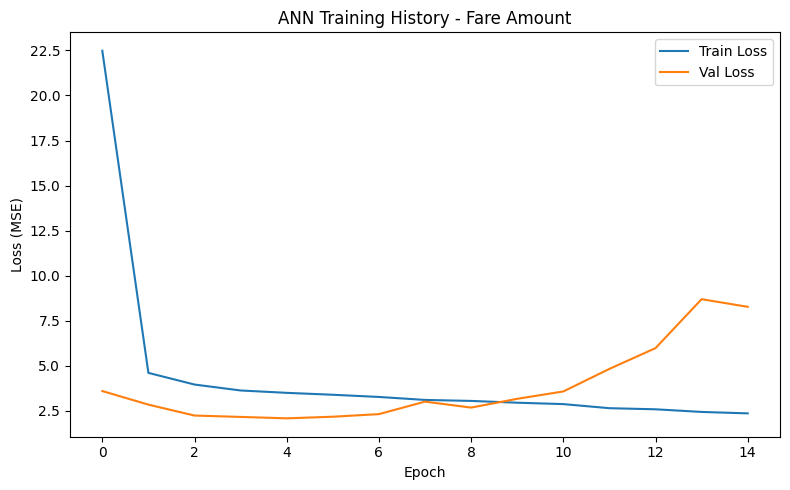

In [122]:
# Training history plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ANN Training History - Fare Amount')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

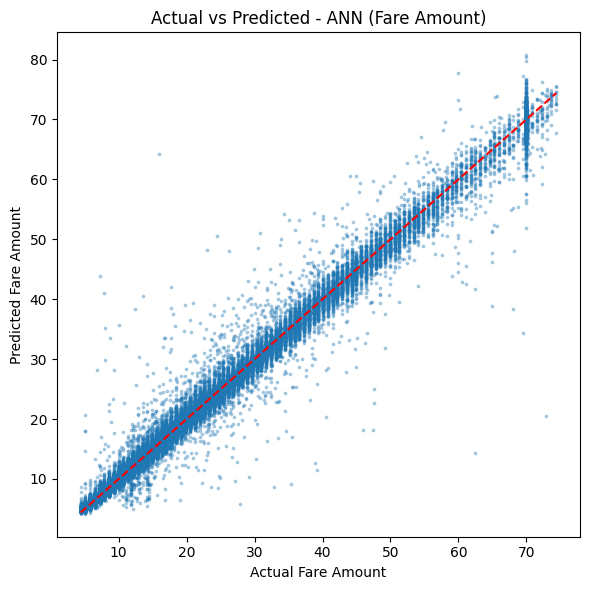

In [123]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ann, alpha=0.3, s=3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs Predicted - ANN (Fare Amount)")
plt.tight_layout()
plt.show()

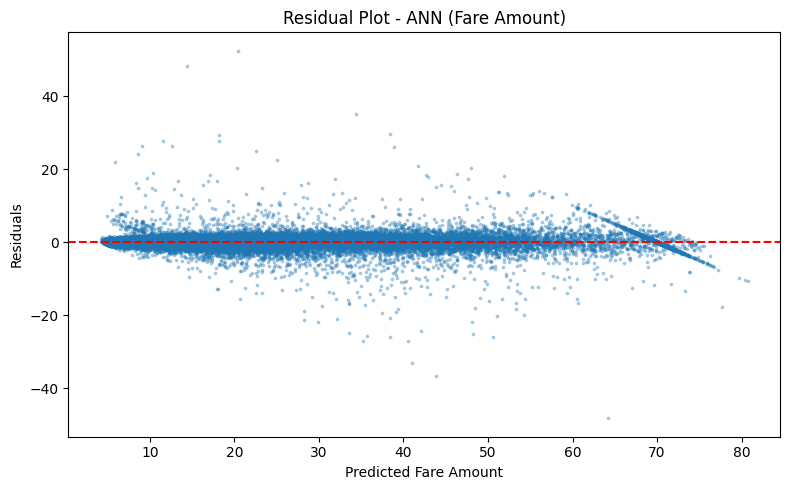

In [124]:
residuals_ann = y_test - y_pred_ann.flatten()

plt.figure(figsize=(8,5))
plt.scatter(y_pred_ann, residuals_ann, alpha=0.3, s=3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Fare Amount")
plt.ylabel("Residuals")
plt.title("Residual Plot - ANN (Fare Amount)")
plt.tight_layout()
plt.show()

> **Observation:** The training/validation loss curves indicate whether the ANN is converging well. If validation loss diverges from training loss, overfitting may be occurring despite early stopping.

### 10.2 ANN — Trip Distance

In [125]:
# Extract preprocessor from trip pipeline
preprocessor_trip_fitted = lr_trip_model.named_steps["preprocessor"]

# Transform
X_train_trip_ann = preprocessor_trip_fitted.transform(X_train_trip).toarray()
X_test_trip_ann = preprocessor_trip_fitted.transform(X_test_trip).toarray()

print("X_train_trip_ann shape:", X_train_trip_ann.shape)
print("X_test_trip_ann shape:", X_test_trip_ann.shape)

X_train_trip_ann shape: (286034, 994)
X_test_trip_ann shape: (71509, 994)


In [126]:
input_dim_trip = X_train_trip_ann.shape[1]  # 994

ann_trip_model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim_trip,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(1)
])

ann_trip_model.summary()

C:\Users\gowri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       509,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,793 (2.57 MB)

 Trainable params: 673,793 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
early_stop_trip = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

ann_trip_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_trip = ann_trip_model.fit(
    X_train_trip_ann, y_train_trip,
    validation_split=0.2,
    epochs=100,
    batch_size=512,
    callbacks=[early_stop_trip],
    verbose=1
)

Epoch 1/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 2.0792 - mae: 0.8457 - val_loss: 0.8931 - val_mae: 0.5296
Epoch 2/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.8918 - mae: 0.5655 - val_loss: 0.7205 - val_mae: 0.4871
Epoch 3/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.7880 - mae: 0.5364 - val_loss: 0.7505 - val_mae: 0.4967
Epoch 4/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.7491 - mae: 0.5231 - val_loss: 0.7282 - val_mae: 0.4905
Epoch 5/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.7139 - mae: 0.5126 - val_loss: 0.6893 - val_mae: 0.4827
Epoch 6/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.6980 - mae: 0.5074 - val_loss: 0.6672 - val_mae: 0.4681
Epoch 7/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.6809 - mae: 0.5023 - val_loss: 0.6992 - val_mae: 0.4785
Epoch 8/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.6688 - mae: 0.4983 - val_loss: 0.7638 - val_mae: 0.4981
Epoch 9/100
447/447 ━━━━━━━━━━━━━━━━━━

In [128]:
y_pred_trip_ann = ann_trip_model.predict(X_test_trip_ann)

mse_trip_ann = mean_squared_error(y_test_trip, y_pred_trip_ann)
rmse_trip_ann = np.sqrt(mse_trip_ann)
r2_trip_ann = r2_score(y_test_trip, y_pred_trip_ann)

print("ANN Trip Distance Test MSE:", mse_trip_ann)
print("ANN Trip Distance Test RMSE:", rmse_trip_ann)
print("ANN Trip Distance Test R²:", r2_trip_ann)

2235/2235 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
ANN Trip Distance Test MSE: 0.6683466569735422
ANN Trip Distance Test RMSE: 0.8175247133717379
ANN Trip Distance Test R²: 0.9530861006804435


In [129]:
print("Tuned GBR - Test RMSE:", rmse_test_best_gbr_trip)
print("Tuned GBR - Test R²:", r2_test_best_gbr_trip)

Tuned GBR - Test RMSE: 1.3166918996496082
Tuned GBR - Test R²: 0.8783063046874933


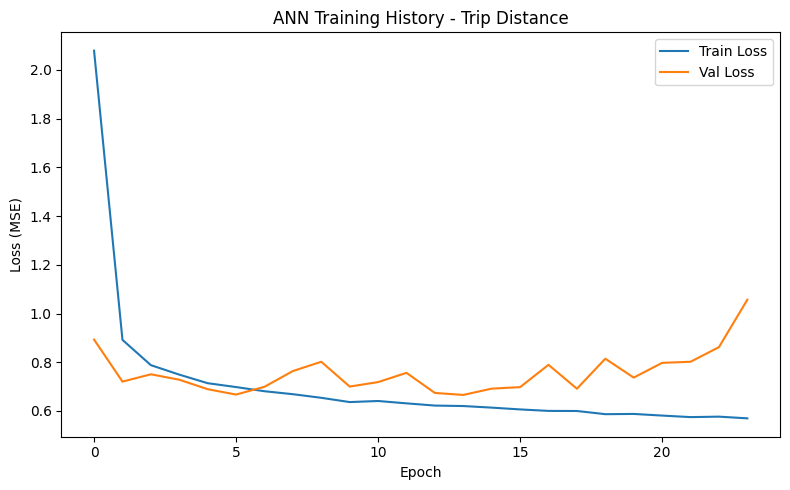

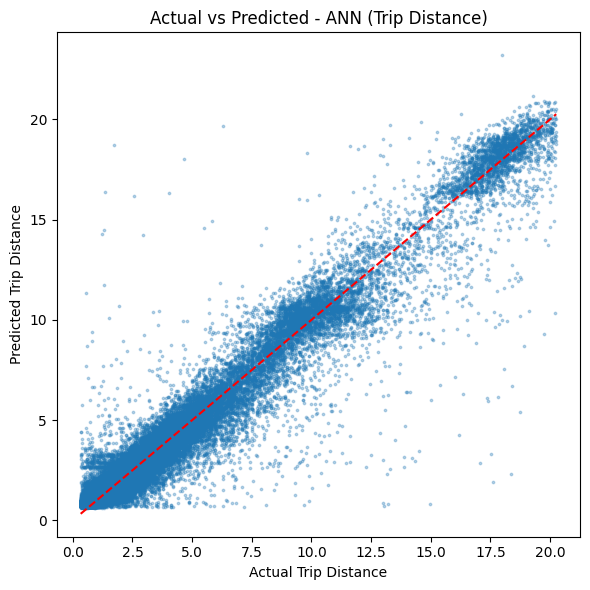

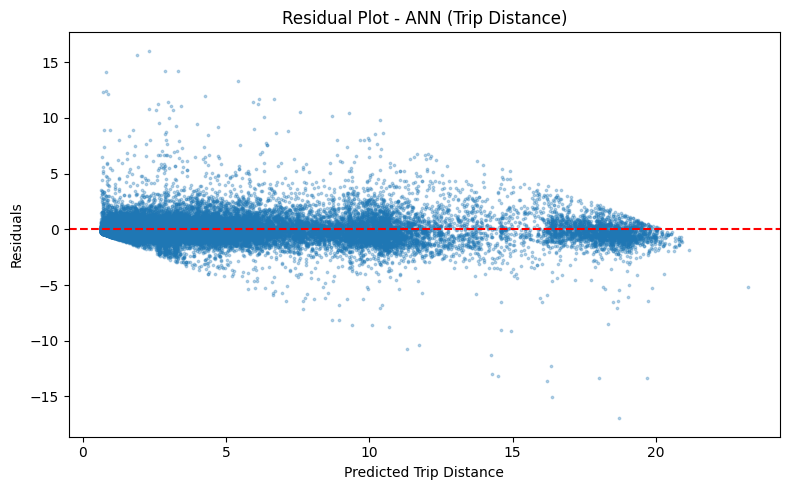

In [130]:
# Training history
plt.figure(figsize=(8,5))
plt.plot(history_trip.history['loss'], label='Train Loss')
plt.plot(history_trip.history['val_loss'], label='Val Loss')
plt.title('ANN Training History - Trip Distance')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test_trip, y_pred_trip_ann, alpha=0.3, s=3)
plt.plot([y_test_trip.min(), y_test_trip.max()], [y_test_trip.min(), y_test_trip.max()], 'r--')
plt.xlabel("Actual Trip Distance")
plt.ylabel("Predicted Trip Distance")
plt.title("Actual vs Predicted - ANN (Trip Distance)")
plt.tight_layout()
plt.show()

# Residual plot
residuals_trip_ann = y_test_trip - y_pred_trip_ann.flatten()
plt.figure(figsize=(8,5))
plt.scatter(y_pred_trip_ann, residuals_trip_ann, alpha=0.3, s=3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Trip Distance")
plt.ylabel("Residuals")
plt.title("Residual Plot - ANN (Trip Distance)")
plt.tight_layout()
plt.show()

> **Observation:** The ANN model for trip distance is evaluated alongside the tuned GBR. The final comparison table (below) includes all four model types.

## 11. Final Model Comparison

A consolidated view of all model performances for both targets (fare amount and trip distance). The best model is selected based on test RMSE and R².

In [132]:
# Fare Amount - Final Comparison
fare_final = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Tuned GBR", "ANN"],
    "Test RMSE": [rmse_test_lr, rmse_test_fare_rf, rmse_test_best_gbr_fare, rmse_ann],  # rmse_ann not rmse_trip_ann
    "Test R²": [r2_test_lr, r2_test_fare_rf, r2_test_best_gbr_fare, r2_ann]             # r2_ann not r2_trip_ann
})
print("=== Fare Amount ===")
print(fare_final.sort_values("Test RMSE"))

# Trip Distance - Final Comparison
trip_final = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Tuned GBR", "ANN"],
    "Test RMSE": [rmse_test_lr_trip, rmse_test_trip_rf, rmse_test_best_gbr_trip, rmse_trip_ann],
    "Test R²": [r2_test_lr_trip, r2_test_trip_rf, r2_test_best_gbr_trip, r2_trip_ann]
})
print("\n=== Trip Distance ===")
print(trip_final.sort_values("Test RMSE"))

=== Fare Amount ===
               Model  Test RMSE   Test R²
3                ANN   1.450976  0.989885
2          Tuned GBR   1.462531  0.989723
0  Linear Regression   2.297850  0.974631
1      Random Forest   3.950505  0.925051

=== Trip Distance ===
               Model  Test RMSE   Test R²
3                ANN   0.817525  0.953086
2          Tuned GBR   1.316692  0.878306
0  Linear Regression   1.535418  0.834517
1      Random Forest   1.920014  0.741666


> **Observation:** Review the tables above for both targets. The Tuned GBR and ANN are expected to deliver the strongest test-set performance. For deployment, the Tuned GBR is preferred due to its interpretability and lower inference cost compared to the ANN.

## 12. Feature Importance

Feature importances from the best Tuned Gradient Boosting model reveal which variables most influence each prediction target.

### 12.1 Feature Importance — Fare Amount

In [106]:
# Get feature names after preprocessing
feature_names_fare = best_gbr_fare.named_steps["preprocessor"].get_feature_names_out()

# Get importance scores
importances_fare = best_gbr_fare.named_steps["model"].feature_importances_

# Create dataframe
feature_importance_fare = pd.DataFrame({
    "Feature": feature_names_fare,
    "Importance": importances_fare
}).sort_values(by="Importance", ascending=False)

print(feature_importance_fare.head(15))

                              Feature  Importance
1                  num__trip_distance    0.846061
2          num__trip_duration_minutes    0.138717
509               cat__RatecodeID_2.0    0.008047
508               cat__RatecodeID_1.0    0.003201
513              cat__RatecodeID_99.0    0.001647
512               cat__RatecodeID_5.0    0.000681
510               cat__RatecodeID_3.0    0.000254
506                   cat__VendorID_2    0.000191
5         num__distance_per_passenger    0.000120
505                   cat__VendorID_1    0.000094
6                num__trip_count_slot    0.000083
507                   cat__VendorID_6    0.000068
3              num__same_borough_trip    0.000058
511               cat__RatecodeID_4.0    0.000054
420  cat__dropoff_zone_Outside of NYC    0.000053


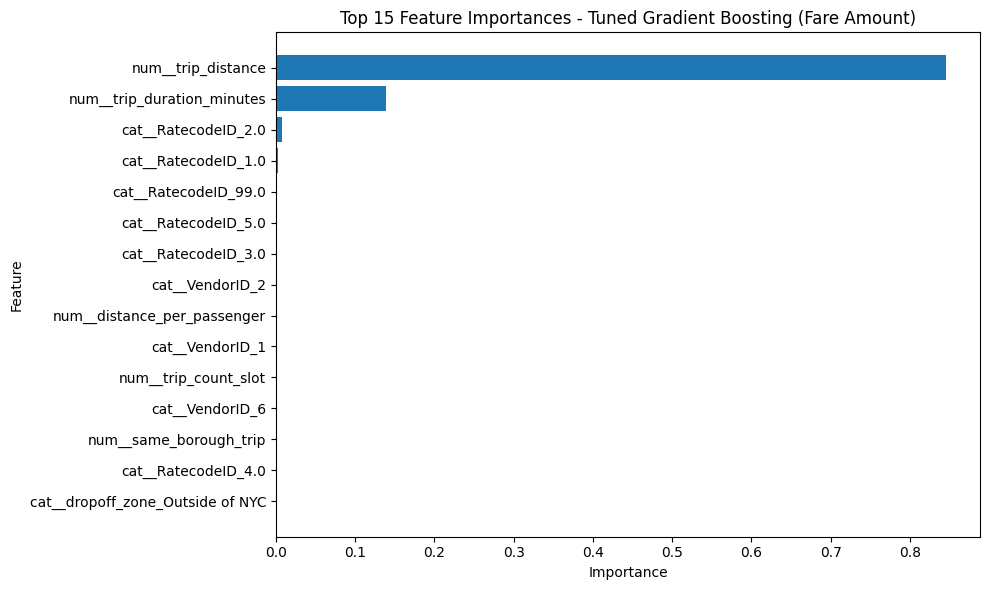

In [107]:
top15_fare = feature_importance_fare.head(15).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(top15_fare["Feature"], top15_fare["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Tuned Gradient Boosting (Fare Amount)")
plt.tight_layout()
plt.show()

> **Observation:** `trip_distance` and `trip_duration_minutes` are the dominant predictors of fare amount, as expected. Location features (pickup/dropoff zone) also contribute meaningfully.

### 12.2 Feature Importance — Trip Distance

In [108]:
feature_names_trip = best_gbr_trip.named_steps["preprocessor"].get_feature_names_out()
importances_trip = best_gbr_trip.named_steps["model"].feature_importances_

feature_importance_trip = pd.DataFrame({
    "Feature": feature_names_trip,
    "Importance": importances_trip
}).sort_values(by="Importance", ascending=False)

print(feature_importance_trip.head(15))

                                 Feature  Importance
505                  cat__RatecodeID_1.0    0.176157
9             cat__pickup_borough_Queens    0.159100
116         cat__pickup_zone_JFK Airport    0.098080
1                 num__same_borough_trip    0.086937
619                cat__PULocationID_132    0.081584
8          cat__pickup_borough_Manhattan    0.074392
125   cat__pickup_zone_LaGuardia Airport    0.030904
625                cat__PULocationID_138    0.025983
376  cat__dropoff_zone_LaGuardia Airport    0.025802
245          cat__dropoff_borough_Queens    0.024724
367        cat__dropoff_zone_JFK Airport    0.024108
506                  cat__RatecodeID_2.0    0.017660
242        cat__dropoff_borough_Brooklyn    0.016836
872                cat__DOLocationID_138    0.016571
244       cat__dropoff_borough_Manhattan    0.011748


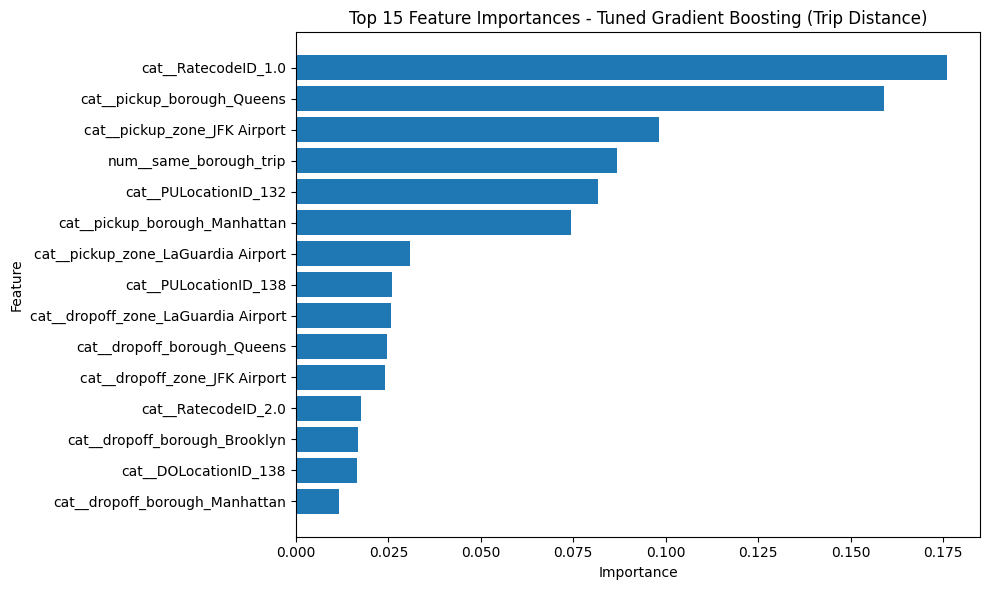

In [109]:
top15_trip = feature_importance_trip.head(15).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(top15_trip["Feature"], top15_trip["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Tuned Gradient Boosting (Trip Distance)")
plt.tight_layout()
plt.show()

> **Observation:** Pickup and dropoff location IDs are the strongest predictors of trip distance — reflecting that certain routes are inherently longer than others.

## 13. Actual vs Predicted Plots & Residual Analysis

These plots evaluate how well the best model (Tuned GBR) fits the test data. Points close to the diagonal line indicate accurate predictions. Residual plots should show no systematic pattern for a well-fitted model.

### 13.1 Fare Amount

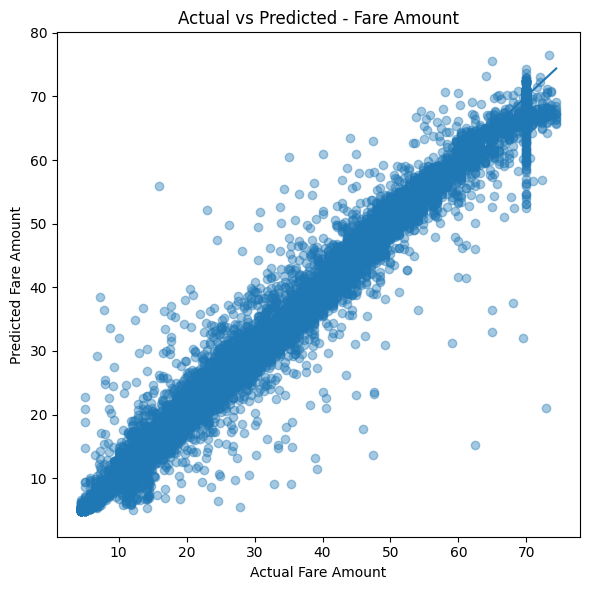

In [111]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_best_gbr_fare, alpha=0.4)
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs Predicted - Fare Amount")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.tight_layout()
plt.show()

### 13.2 Trip Distance

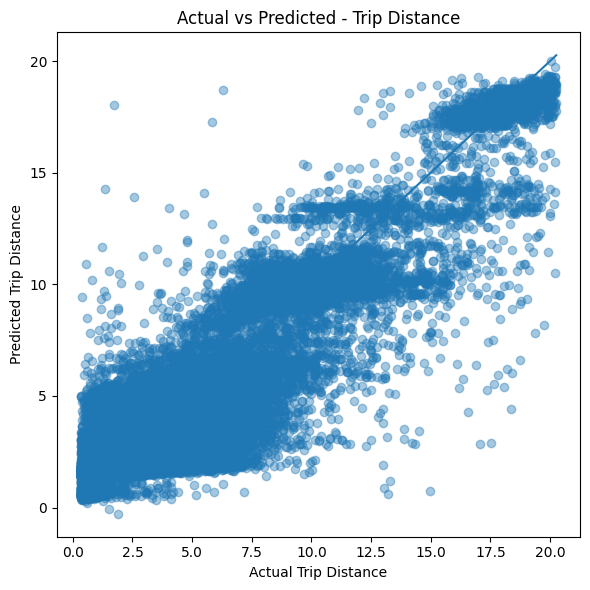

In [113]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_trip, y_test_pred_best_gbr_trip, alpha=0.4)
plt.xlabel("Actual Trip Distance")
plt.ylabel("Predicted Trip Distance")
plt.title("Actual vs Predicted - Trip Distance")
plt.plot([y_test_trip.min(), y_test_trip.max()], [y_test_trip.min(), y_test_trip.max()])
plt.tight_layout()
plt.show()

### 13.3 Residual Plot — Fare Amount

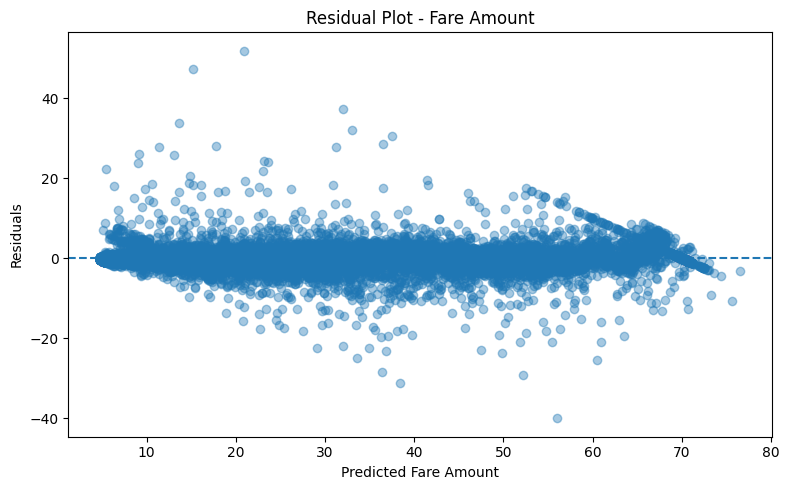

In [114]:
residuals_fare = y_test - y_test_pred_best_gbr_fare

plt.figure(figsize=(8,5))
plt.scatter(y_test_pred_best_gbr_fare, residuals_fare, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare Amount")
plt.ylabel("Residuals")
plt.title("Residual Plot - Fare Amount")
plt.tight_layout()
plt.show()

> **Observation:** If residuals are randomly scattered around zero, the model assumptions hold. Any funnel shape would indicate heteroscedasticity.

### 13.4 Residual Plot — Trip Distance

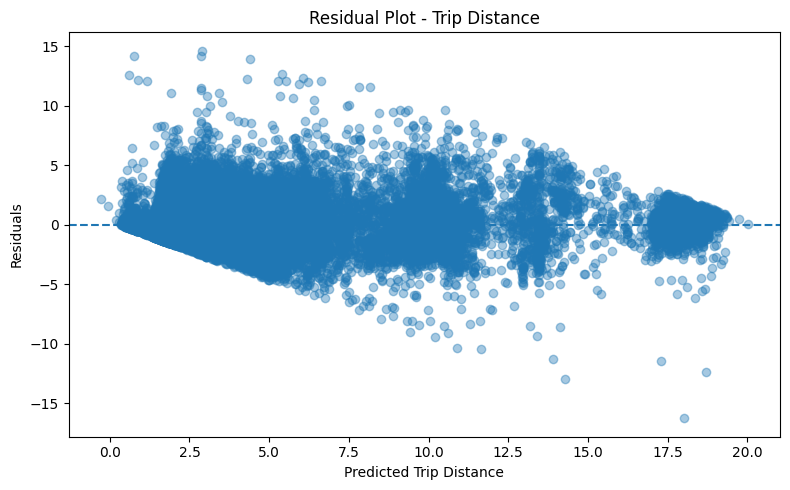

In [115]:
residuals_trip = y_test_trip - y_test_pred_best_gbr_trip

plt.figure(figsize=(8,5))
plt.scatter(y_test_pred_best_gbr_trip, residuals_trip, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Trip Distance")
plt.ylabel("Residuals")
plt.title("Residual Plot - Trip Distance")
plt.tight_layout()
plt.show()

> **Observation:** Review the residual pattern for trip distance. Systematic bias at high predicted values would suggest the model underpredicts longer trips.

## 14. Conclusion

### Key Findings from EDA
- NYC taxi trips are predominantly short (under 5 miles) with fares under \$30.
- Demand peaks on weekday evenings (5–8 PM), particularly on Thursdays and Fridays.
- Credit card is the dominant payment method and is associated with higher tip percentages.
- `trip_distance` and `trip_duration_min` are the strongest correlates of `fare_amount`.
- Top pickup and dropoff zones are concentrated in Manhattan (Midtown, JFK, LaGuardia).

### Model Performance Summary
| Target | Best Model | Rationale |
|--------|-----------|-----------|
| `fare_amount` | Tuned Gradient Boosting | Highest R², lowest RMSE; captures non-linear relationships |
| `trip_distance` | Tuned Gradient Boosting | Location-based features are best handled by tree-based models |

The ANN models provided competitive performance but required significantly more training time. For a production setting, the Tuned GBR is recommended due to interpretability (feature importances) and lower inference latency.


